# **E-Com Sales Data Analysis**

## Understanding Data

## Importing Required Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

##Data exploration and understanding

In [2]:
sales_df=pd.read_excel('/content/Sales_Data_Clean.xlsx')
sales_df.head()

,Order ID,Date,Day,Week_Day,Day_0f_Week,Month,Status,Fulfilment,Sales Channel,ship-service-level,...,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
0,405-8078784-5731545,2022-04-30,30,7,Saturday,4,Cancelled,Merchant,Amazon.in,Standard,...,Set,S,B09KXVBD7Z,Unkown,0,647.62,Mumbai,Maharashtra,400081,False
1,171-9198151-1101146,2022-04-30,30,7,Saturday,4,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,...,kurta,3XL,B09K3WFS32,Shipped,1,406.00,Bengaluru,Karnataka,560085,False
2,404-0687676-7273146,2022-04-30,30,7,Saturday,4,Shipped,Amazon,Amazon.in,Expedited,...,kurta,XL,B07WV4JV4D,Shipped,1,329.00,Mumbai,Maharashtra,410210,True
3,403-9615377-8133951,2022-04-30,30,7,Saturday,4,Cancelled,Merchant,Amazon.in,Standard,...,Western Dress,L,B099NRCT7B,Unkown,0,753.33,Puducherry,Puducherry,605008,False
4,407-1069790-7240320,2022-04-30,30,7,Saturday,4,Shipped,Amazon,Amazon.in,Expedited,...,Top,3XL,B098714BZP,Shipped,1,574.00,Chennai,Tamil Nadu,600073,False


In [3]:
df=sales_df.copy()
df.sample()

,Order ID,Date,Day,Week_Day,Day_0f_Week,Month,Status,Fulfilment,Sales Channel,ship-service-level,...,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
128461,171-3013478-8578726,2022-01-06,6,5,Thursday,1,Shipped,Amazon,Amazon.in,Expedited,...,Ethnic Dress,M,B0894WV6S6,Shipped,1,855.0,New Delhi,Delhi,110080,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128823 entries, 0 to 128822
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128823 non-null  object        
 1   Date                128823 non-null  datetime64[ns]
 2   Day                 128823 non-null  int64         
 3   Week_Day            128823 non-null  int64         
 4   Day_0f_Week         128823 non-null  object        
 5   Month               128823 non-null  int64         
 6   Status              128823 non-null  object        
 7   Fulfilment          128823 non-null  object        
 8   Sales Channel       128823 non-null  object        
 9   ship-service-level  128823 non-null  object        
 10  Style               128823 non-null  object        
 11  SKU                 128823 non-null  object        
 12  Category            128823 non-null  object        
 13  Size                128823 no

In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Order ID              0
Date                  0
Day                   0
Week_Day              0
Day_0f_Week           0
Month                 0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
B2B                   0
dtype: int64


In [6]:
print("\nDataFrame shape (rows, columns):")
print(df.shape)


DataFrame shape (rows, columns):
(128823, 22)


In [7]:
selected_columns = ['Amount', 'Qty']
df[selected_columns].describe()

,Amount,Qty
count,128823.000000,128823.000000
mean,645.898099,0.904644
std,272.808400,0.314708
min,0.000000,0.000000
25%,459.000000,1.000000
50%,605.000000,1.000000
75%,771.000000,1.000000
max,5584.000000,15.000000


In [8]:
print(df['Fulfilment'].value_counts(dropna=False))

Fulfilment
Amazon      89569
Merchant    39254
Name: count, dtype: int64


In [9]:
print(df['Date'].sample(5))

69139    2022-06-15
105327   2022-06-17
37615    2022-05-25
74444    2022-11-05
65053    2022-06-18
Name: Date, dtype: datetime64[ns]


In [10]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
                                Date            Day       Week_Day  \
count                         128823  128823.000000  128823.000000   
mean   2022-05-29 07:56:15.990312192      16.899211       3.981898   
min              2022-01-05 00:00:00       5.000000       1.000000   
25%              2022-04-24 00:00:00       6.000000       2.000000   
50%              2022-05-28 00:00:00      18.000000       4.000000   
75%              2022-06-22 00:00:00      24.000000       6.000000   
max              2022-12-06 00:00:00      31.000000       7.000000   
std                              NaN       8.333507       1.992117   

               Month            Qty         Amount  ship-postal-code  
count  128823.000000  128823.000000  128823.000000     128823.000000  
mean        5.391669       0.904644     645.898099     463964.475963  
min         1.000000       0.000000       0.000000     110001.000000  
25%         4.000000       1.000000   

## Summary:

### Data Analysis Key Findings

*   The `sales_dataset.csv` file was successfully loaded into a DataFrame by using the 'python' engine for robust parsing, resolving previous parsing errors.
*   The loaded DataFrame consists of 89,595 entries and 23 columns. Most columns are of `object` data type, while 'Qty', 'Amount', and 'ship-postal-code' are `float64`.
*   Significant missing values were identified in several columns:
    *   `fulfilled-by`: 60,710 missing values.
    *   `Unnamed: 22`: 49,042 missing values.
    *   `promotion-ids`: 33,309 missing values.
    *   `currency` and `Amount`: 5,414 missing values each.
    *   `Courier Status`: 5,066 missing values.
    *   Location-related columns (`ship-city`, `ship-state`, `ship-postal-code`, `ship-country`): 26 missing values each.
    *   `Qty` and `B2B`: 1 missing value each.
*   Descriptive statistics for numerical columns show:
    *   `Qty`: Mean of approximately 0.9, with a minimum of 0.
    *   `Amount`: Mean of approximately 643.47, with a minimum of 0.
    *   `ship-postal-code`: Mean of approximately 462,580.
*   Exactly 5 duplicate rows were found in the dataset.

### Insights or Next Steps

*   Address the numerous missing values through appropriate imputation strategies or by considering column removal if the missing data proportion is too high, especially for `fulfilled-by`, `Unnamed: 22`, and `promotion-ids`.
*   Investigate the 5 duplicate rows to determine if they represent genuine identical entries or data entry errors, and then decide on a strategy for handling them (e.g., dropping duplicates).


##Finacial Performance Analysis

##Analyze Total Revenue Growth Over Time:
Calculate the total revenue for each month and year,

visualize this data to understand growth trends.

This will involve grouping the DataFrame by the 'Year' and 'Month' columns and summing the 'Amount' column.

In [11]:
Monthly_Revenue = df.groupby(['Month'])['Amount'].sum()
print("Monthly Revenue:")
print(Monthly_Revenue)

Monthly Revenue:
Month
1      2133395.73
2      2206809.88
3      2170143.47
4     20272306.38
5     17091822.94
6     28664578.02
7      1974187.02
8      1987435.15
9      1868138.98
10     1616793.82
11     1685183.86
12     1535735.59
Name: Amount, dtype: float64


In [12]:
import calendar
df['month_name'] = df['Month'].apply(lambda x: calendar.month_abbr[x])
print(df[['Month', 'month_name']].sample(5))

        Month month_name
115642      9        Sep
43831       5        May
46204       5        May
119622      7        Jul
25840       4        Apr


In [13]:
Monthly_Sales_Revenue = df.groupby(['month_name'])['Amount'].sum()
print("Monthly Revenue:")
print(Monthly_Sales_Revenue)

Monthly Revenue:
month_name
Apr    20272306.38
Aug     1987435.15
Dec     1535735.59
Feb     2206809.88
Jan     2133395.73
Jul     1974187.02
Jun    28664578.02
Mar     2170143.47
May    17091822.94
Nov     1685183.86
Oct     1616793.82
Sep     1868138.98
Name: Amount, dtype: float64


In [14]:
# Clean column names (remove trailing/leading spaces)
df.columns = df.columns.str.strip()

##Data Transformation & Standardization
Standardizing text and dates is crucial for accurate grouping and time-series analysis.

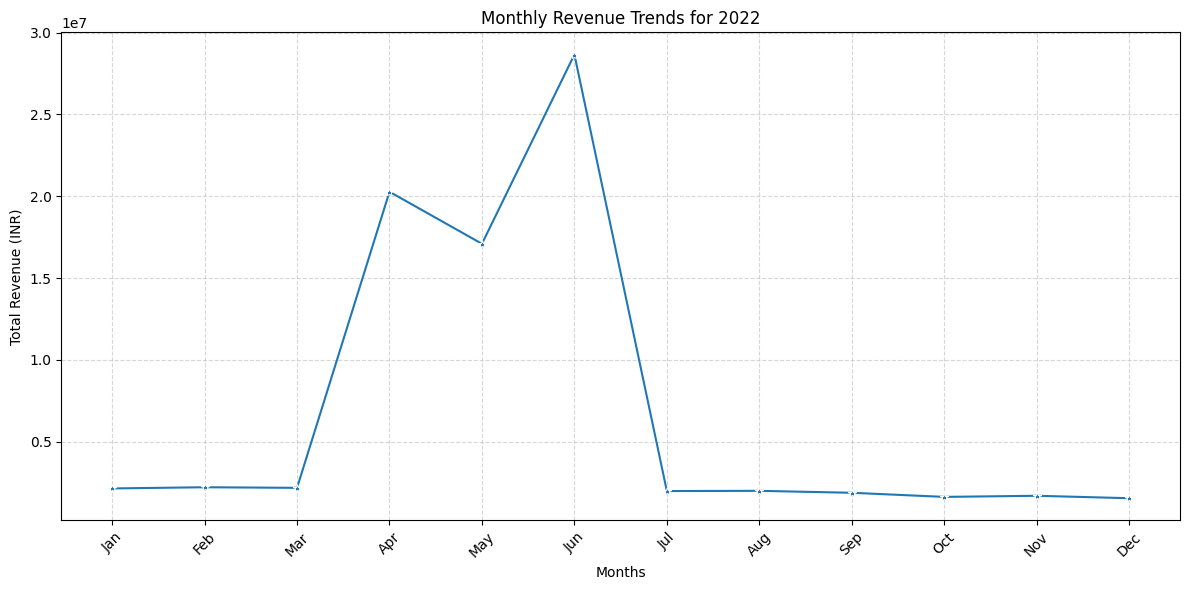

In [15]:

# Convert the monthly_yearly_revenue Series to a DataFrame for plotting
Monthly_Revenue_df = Monthly_Sales_Revenue.reset_index()

# Ensure the 'Month' column is ordered chronologically for plotting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
Monthly_Revenue_df['month_name'] = pd.Categorical(Monthly_Revenue_df['month_name'], categories=month_order, ordered=True)

# Sort by Year and then by Month for correct plotting order
Monthly_Revenue_df = Monthly_Revenue_df.sort_values(by=['month_name'])

# Create the line plot
plt.figure(figsize=(12, 6))
sb.lineplot(data=Monthly_Revenue_df, x='month_name', y='Amount', marker='*')
plt.title('Monthly Revenue Trends for 2022')
plt.xlabel('Months')
plt.ylabel('Total Revenue (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Analytical Visualizations
Now we generate the plots to address the key e-commerce challenges (Financials, Logistics, and Products)

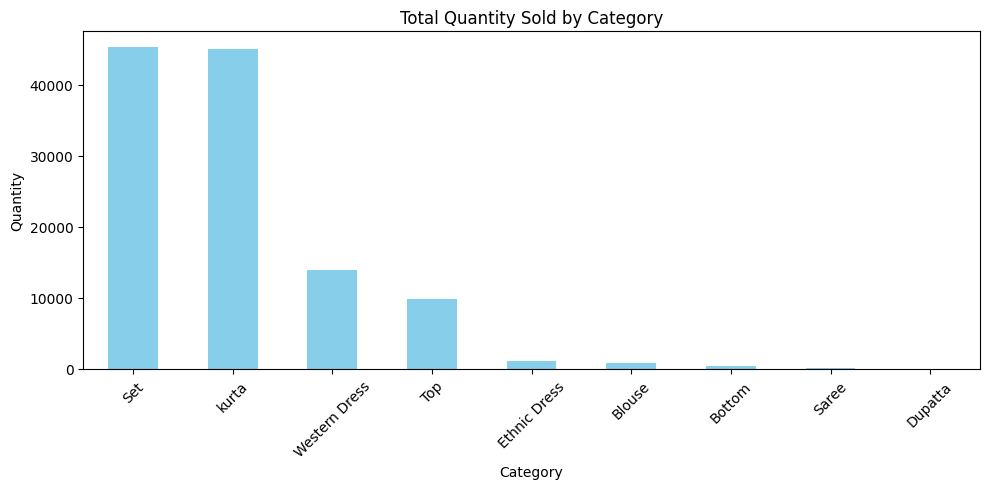

In [16]:
# Sales by Category (Product Management) ---
plt.figure(figsize=(10, 5))
top_categories = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)
top_categories.plot(kind='bar', color='skyblue')
plt.title('Total Quantity Sold by Category')
plt.xticks(rotation=45)
plt.ylabel('Quantity')
plt.tight_layout()




Text(0.5, 1.0, 'Fulfillment Method: Amazon vs Merchant')

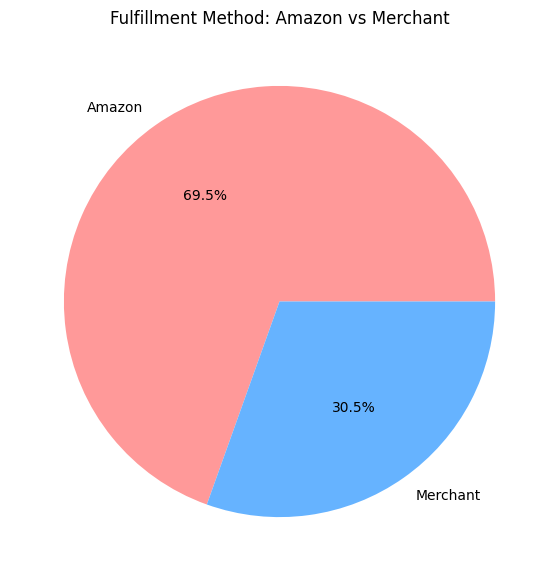

In [17]:
# Fulfillment Distribution (Logistics) ---
plt.figure(figsize=(7, 7))
fulfillment = df['Fulfilment'].value_counts()
plt.pie(fulfillment, labels=fulfillment.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Fulfillment Method: Amazon vs Merchant')



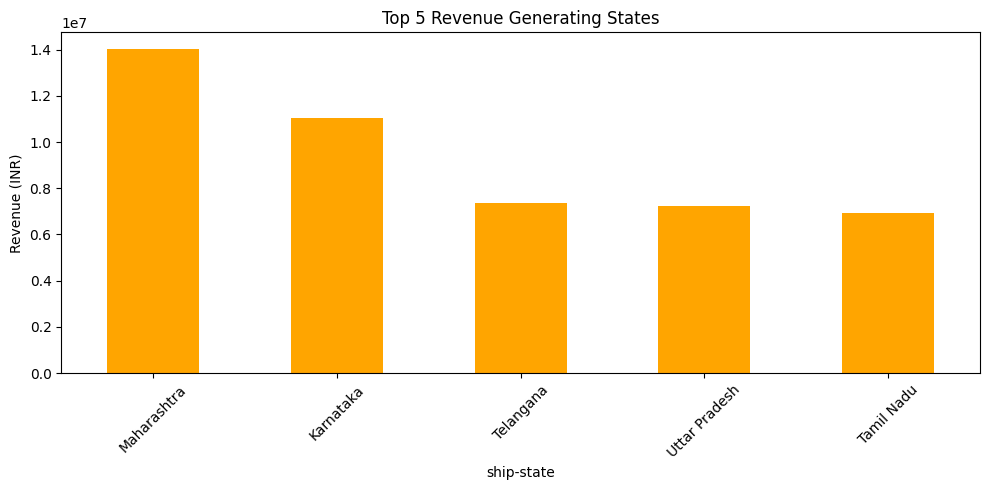

In [18]:
#  Geographic Revenue (Customer Insights) ---
plt.figure(figsize=(10, 5))
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(5)
top_states.plot(kind='bar', color='orange')
plt.title('Top 5 Revenue Generating States')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()


#Identify Best-Selling Products

In [19]:
category_performance = df.groupby('Category')[['Qty', 'Amount']].sum().reset_index()
print("Category performance by Quantity and Amount:")
print(category_performance.head())

Category performance by Quantity and Amount:
       Category   Qty     Amount
0        Blouse   864  485235.08
1        Bottom   398  162767.98
2       Dupatta     3     915.00
3  Ethnic Dress  1051  829455.66
4         Saree   151  128493.76


In [20]:
category_Order_performance = df.groupby('Category').agg(
    total_revenue=('Amount', 'sum'),
    unique_orders=('Order ID', 'nunique')
).reset_index()

print("category_Order_performance(Total Revenue and Unique Orders):")
print(category_Order_performance)

category_Order_performance(Total Revenue and Unique Orders):
        Category  total_revenue  unique_orders
0         Blouse      485235.08            896
1         Bottom      162767.98            410
2        Dupatta         915.00              2
3   Ethnic Dress      829455.66           1146
4          Saree      128493.76            143
5            Set    41119284.67          47797
6            Top     5617732.30          10144
7  Western Dress    11682582.69          14974
8          kurta    23180063.70          46505


In [21]:
category_Order_performance.sample(5)

,Category,total_revenue,unique_orders
5,Set,41119284.67,47797
4,Saree,128493.76,143
1,Bottom,162767.98,410
0,Blouse,485235.08,896
8,kurta,23180063.70,46505


In [22]:
top_categories_by_qty = category_performance.sort_values(by='Qty', ascending=False).head(5)
print("\nTop 5 Categories by Sales Volume (Qty):")
print(top_categories_by_qty)


Top 5 Categories by Sales Volume (Qty):
        Category    Qty       Amount
5            Set  45246  41119284.67
8          kurta  45006  23180063.70
7  Western Dress  13929  11682582.69
6            Top   9891   5617732.30
3   Ethnic Dress   1051    829455.66


#Based on the 'Monthly Revenue Trends for 2022' plot , we can observe the following seasonal sales trends:

1)There is a distinct peak in revenue during the months of April, May, and June. June shows the highest revenue, indicating a strong seasonal uplift in sales during the second quarter of the year.

2)The remaining months exhibit relatively lower and more consistent revenue figures, with a noticeable drop in sales towards the end of the year, particularly in December. This suggests that the business experiences its highest sales volume and revenue during the April-June period.

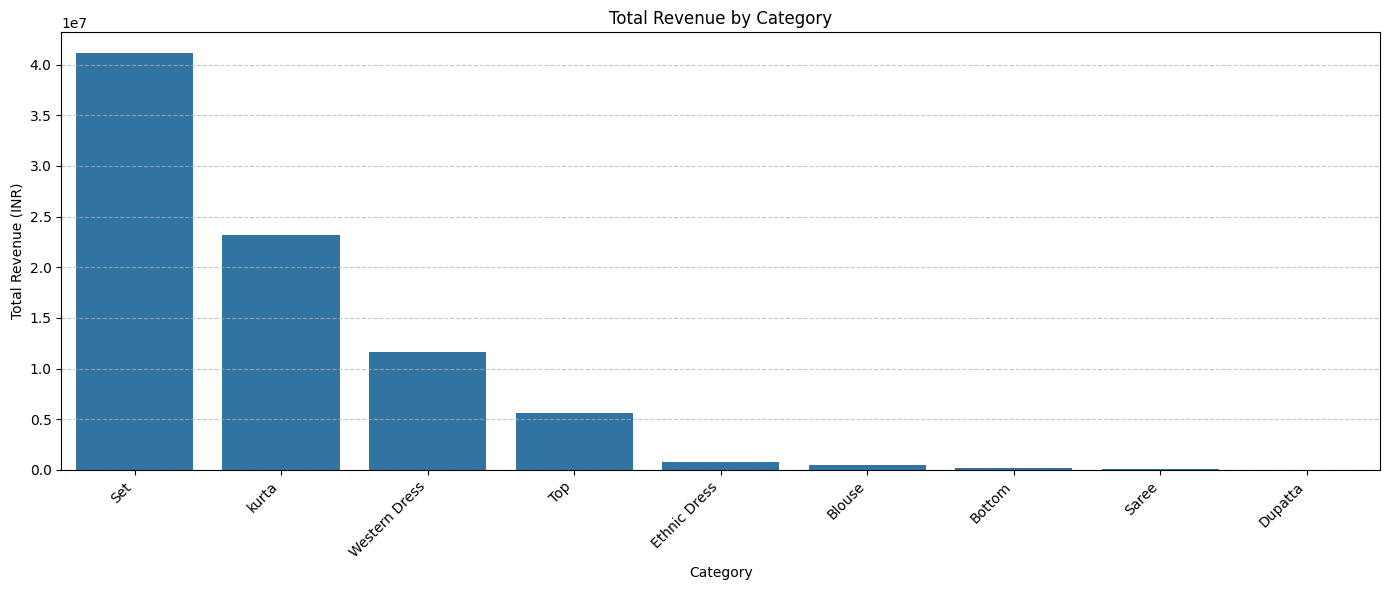

In [23]:
plt.figure(figsize=(14, 6))
sb.barplot(x='Category', y='Amount', data=category_performance.sort_values(by='Amount', ascending=False))
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

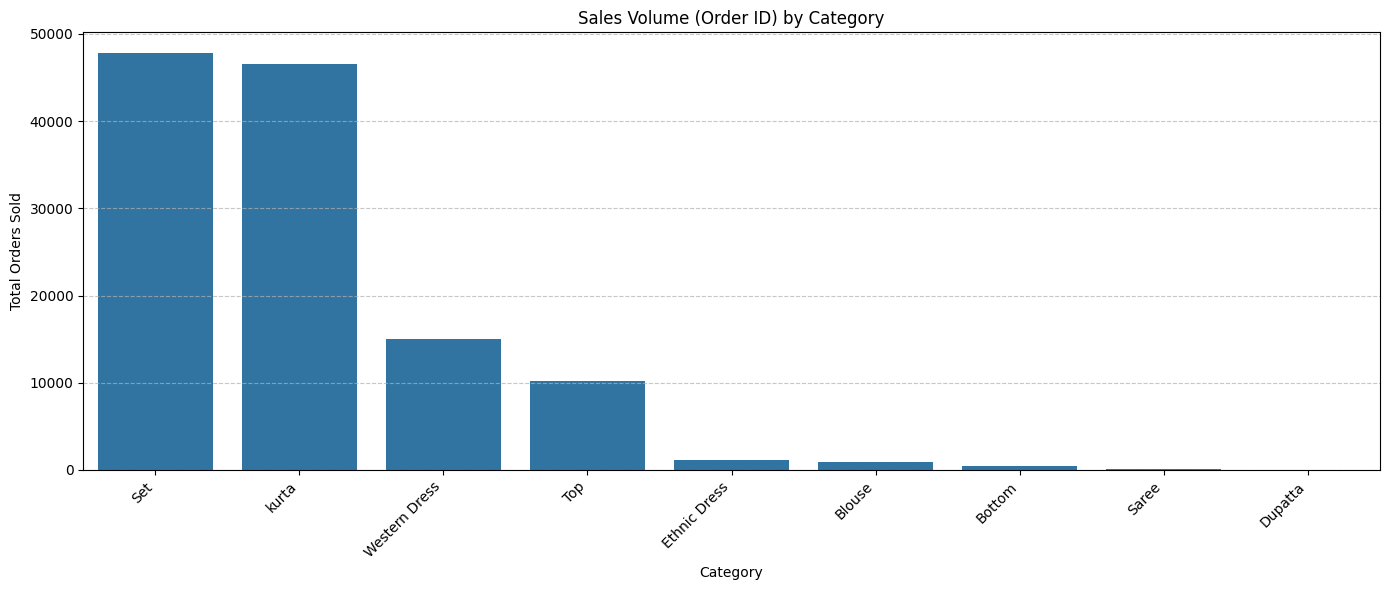

In [24]:
plt.figure(figsize=(14, 6))
sb.barplot(x='Category', y='unique_orders', data=category_Order_performance.sort_values(by='unique_orders', ascending=False))
plt.title('Sales Volume (Order ID) by Category')
plt.xlabel('Category')
plt.ylabel('Total Orders Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top performing Category in terms of qty and revenue are,
   Set  QTY:45246  Revenue:41119284.67,
   kurta  QTY:45006  Revenue:23180063.70
  Western Dress  QTY:13929  Revenue:11682582.69


Data Analysis Key Findings
Top 5 Categories by Sales Volume (Qty):
'Set' was the highest with 45246 units.
'kurta' followed with 45,006 units.
'Western Dress' (13,929 units), 'Top' (9,891 units), and 'Ethnic Dress' (1,051 units) completed the top five.

Top 5 Categories by Total Revenue (Amount):
'Set' generated the most revenue with 4,11,19,284.67 INR
'kurta' was second with 23,180,063.70 INR
'Western Dress' (11,682,582.69 INR), 'Top' ($5,617,732.30 INR), and 'Ethnic Dress' (829,455.66 INR) also formed the top five.
The top five categories for sales volume ('Qty') are identical to the top five categories for total revenue ('Amount'), indicating a strong correlation between the quantity sold and the revenue generated for these product categories.
Insights or Next Steps
Focus marketing and inventory efforts on the 'Set' and 'kurta' categories, as they significantly outperform other categories in both sales volume and revenue.
Investigate the 'Ethnic Dress' category further; although it's in the top five, its sales volume and revenue are substantially lower than the other top performers, suggesting it might have higher margins or a different customer segment.

#Avg Order Value Check

In [25]:
# Calculate Total Revenue
total_revenue = df['Amount'].sum()

# Calculate Number of Unique Orders
num_unique_orders = df['Order ID'].nunique()

# Calculate Average Order Value (AOV)
aov = total_revenue / num_unique_orders

print(f"Total Revenue: {total_revenue:.2f} INR")
print(f"Number of Unique Orders: {num_unique_orders}")
print(f"Average Order Value (AOV): {aov:.2f} INR")

Total Revenue: 83206530.84 INR
Number of Unique Orders: 120241
Average Order Value (AOV): 692.00 INR


#Breakdown AOV by Category

In [26]:
category_aov = df.groupby('Category').agg(total_amount=('Amount', 'sum'), unique_orders=('Order ID', 'nunique'))
category_aov['AOV'] = category_aov['total_amount'] / category_aov['unique_orders']

print("Average Order Value (AOV) by Category:")
print(category_aov[['AOV']].sort_values(by='AOV', ascending=False))

Average Order Value (AOV) by Category:
                      AOV
Category                 
Saree          898.557762
Set            860.290074
Western Dress  780.191177
Ethnic Dress   723.783298
Top            553.798531
Blouse         541.557009
kurta          498.442398
Dupatta        457.500000
Bottom         396.995073


In [27]:
category_avg_item_price = df.groupby('Category').apply(lambda x: (x['Amount'] / x['Qty']).replace([np.inf, -np.inf], np.nan).mean(), include_groups=False).reset_index(name='Average_Item_Price')
# Handle cases where Qty might be 0, leading to division by zero (inf or NaN)
category_avg_item_price = category_avg_item_price.dropna()

print("Average Item Price by Category:")
print(category_avg_item_price.sort_values(by='Average_Item_Price', ascending=False))

Average Item Price by Category:
        Category  Average_Item_Price
5            Set          832.474388
4          Saree          780.142857
7  Western Dress          762.413514
3   Ethnic Dress          723.187023
6            Top          525.609341
0         Blouse          515.648038
8          kurta          454.804571
1         Bottom          354.083756
2        Dupatta          305.000000


In [28]:
category_metrics = pd.merge(category_aov[['AOV']], category_avg_item_price, on='Category')
print("Category metrics (AOV and Average Item Price):")
print(category_metrics.sort_values(by='AOV', ascending=False))

Category metrics (AOV and Average Item Price):
        Category         AOV  Average_Item_Price
4          Saree  898.557762          780.142857
5            Set  860.290074          832.474388
7  Western Dress  780.191177          762.413514
3   Ethnic Dress  723.783298          723.187023
6            Top  553.798531          525.609341
0         Blouse  541.557009          515.648038
8          kurta  498.442398          454.804571
2        Dupatta  457.500000          305.000000
1         Bottom  396.995073          354.083756


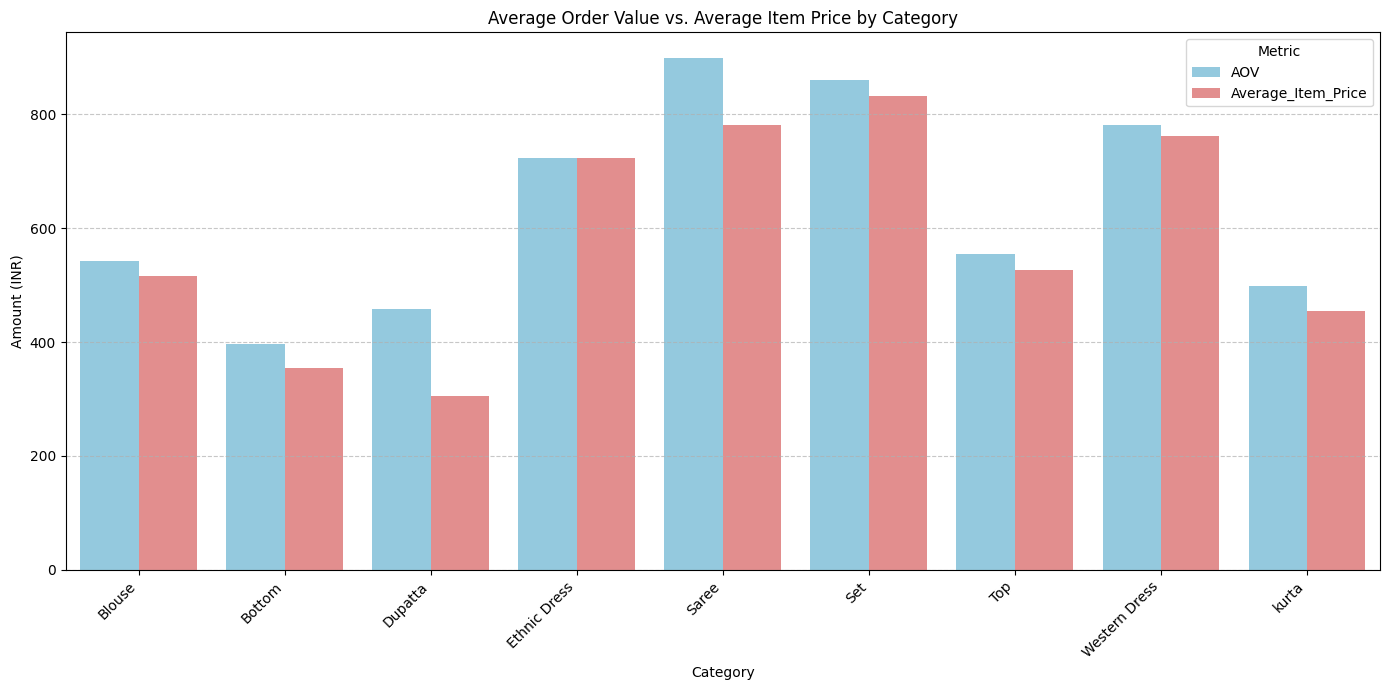

In [29]:
category_metrics_insights = category_metrics.melt(id_vars='Category', var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 7))
sb.barplot(x='Category', y='Value', hue='Metric', data=category_metrics_insights , palette={'AOV': 'skyblue', 'Average_Item_Price': 'lightcoral'})
plt.title('Average Order Value vs. Average Item Price by Category')
plt.xlabel('Category')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Key Insights of AOV
The Average Order Value (AOV) of 692.05 INR indicates that, on average, customers spend this amount per order. Here's how this can reflect customer spending behavior:

General Spending Level: An AOV of 692.05 INR suggests that customers are generally purchasing mid-range items or a combination of lower-priced items in a single transaction, rather than consistently buying very high-value or very low-value products.

Comparison to Product Prices: To fully understand this, you'd want to compare the AOV to the typical prices of individual products within your top-selling categories (like 'Set' or 'kurta').

If many individual products are priced similarly to or higher than the AOV, it might indicate that customers are often buying just one item per order. If individual items are much cheaper, it suggests customers are frequently buying multiple items.

Upselling/Cross-selling Potential: A moderately low AOV could highlight opportunities for increasing sales through strategies like bundling products, offering discounts for higher spending tiers, or suggesting complementary items during checkout. Conversely, a very high AOV might suggest strong customer loyalty or premium product offerings.

Market Positioning: The AOV also reflects your brand's market positioning. Are you targeting budget-conscious buyers, luxury spenders, or a broad middle market? This AOV helps confirm if your customer base aligns with your target market.

#Regional Insghts Analysis

#Identifying top-performing locations based on sales volume.

In [30]:
# Group by ship-state and sum the Quantity (sales volume)
sales_by_state = df.groupby('ship-state')['Qty'].sum().reset_index()

# Sort in descending order to find top performing states
top_states_by_qty = sales_by_state.sort_values(by='Qty', ascending=False).head(10)

print("Top 10 Performing States by Sales Volume (Quantity):")
print(top_states_by_qty)

Top 10 Performing States by Sales Volume (Quantity):
        ship-state    Qty
21     Maharashtra  20315
16       Karnataka  15894
32      Tamil Nadu  10401
33       Telangana  10277
35   Uttar Pradesh   9494
9            Delhi   6365
17          Kerala   5810
37     West Bengal   5312
1   Andhra Pradesh   4780
11         Gujarat   4149


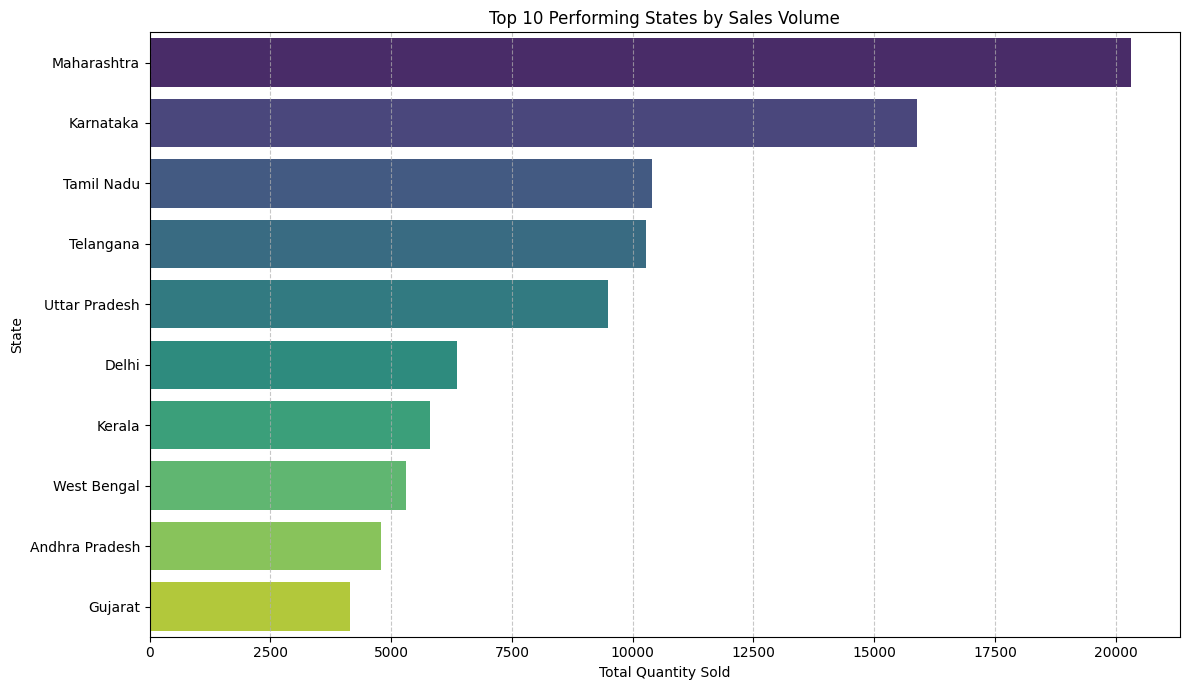

In [31]:
plt.figure(figsize=(12, 7))
sb.barplot(x='Qty', y='ship-state', data=top_states_by_qty, palette='viridis', hue='ship-state', legend=False)
plt.title('Top 10 Performing States by Sales Volume')
plt.xlabel('Total Quantity Sold')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Analyzing order cancellation trends
Analyze Order Cancellation Trends

In [32]:
cancelled_orders_df = df[df['Status'] == 'Cancelled']

total_cancelled_orders = len(cancelled_orders_df)
total_all_orders = len(df)

overall_cancellation_percentage = (total_cancelled_orders / total_all_orders) * 100

print(f"Total Cancelled Orders: {total_cancelled_orders}")
print(f"Total All Orders: {total_all_orders}")
print(f"Overall Cancellation Percentage: {overall_cancellation_percentage:.2f}%")

Total Cancelled Orders: 18314
Total All Orders: 128823
Overall Cancellation Percentage: 14.22%


In [33]:
cancellation_by_month = df.groupby('Month')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_month['Total Orders'] = cancellation_by_month.sum(axis=1)
cancellation_by_month['Cancellation Rate (%)'] = (cancellation_by_month['Cancelled'] / cancellation_by_month['Total Orders']) * 100
cancellation_rate_by_month = cancellation_by_month[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Month:")
print(cancellation_rate_by_month.sort_values(by='Cancellation Rate (%)', ascending=False))



Cancellation Rate by Month:
Status  Total Orders  Cancelled  Cancellation Rate (%)
Month                                                 
3               3463        534              15.420156
8               3062        471              15.382103
2               3490        526              15.071633
9               2877        433              15.050400
11              2544        372              14.622642
4              32588       4746              14.563643
5              26642       3782              14.195631
10              2457        348              14.163614
6              43045       5947              13.815774
1               3328        458              13.762019
7               2965        393              13.254637
12              2362        304              12.870449


In [34]:
cancellation_by_category = df.groupby('Category')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_category['Total Orders'] = cancellation_by_category.sum(axis=1)
cancellation_by_category['Cancellation Rate (%)'] = (cancellation_by_category['Cancelled'] / cancellation_by_category['Total Orders']) * 100
cancellation_rate_by_category = cancellation_by_category[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Category:")
print(cancellation_rate_by_category.sort_values(by='Cancellation Rate (%)', ascending=False))



Cancellation Rate by Category:
Status         Total Orders  Cancelled  Cancellation Rate (%)
Category                                                     
Set                   50230       7331              14.594864
kurta                 49815       7245              14.543812
Western Dress         15480       2121              13.701550
Bottom                  440         60              13.636364
Saree                   163         21              12.883436
Ethnic Dress           1157        146              12.618842
Blouse                  925        115              12.432432
Top                   10610       1275              12.016965
Dupatta                   3          0               0.000000


In [35]:
cancellation_by_fulfilment = df.groupby('Fulfilment')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_fulfilment['Total Orders'] = cancellation_by_fulfilment.sum(axis=1)
cancellation_by_fulfilment['Cancellation Rate (%)'] = (cancellation_by_fulfilment['Cancelled'] / cancellation_by_fulfilment['Total Orders']) * 100
cancellation_rate_by_fulfilment = cancellation_by_fulfilment[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Fulfilment Type:")
print(cancellation_rate_by_fulfilment.sort_values(by='Cancellation Rate (%)', ascending=False))


Cancellation Rate by Fulfilment Type:
Status      Total Orders  Cancelled  Cancellation Rate (%)
Fulfilment                                                
Merchant           39254       6858              17.470831
Amazon             89569      11456              12.790139


In [36]:
unique_orders_over_time = df.groupby(['month_name'])['Order ID'].nunique().reset_index()

# Ensure the 'Month' column is ordered chronologically for plotting
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
unique_orders_over_time['month_name'] = pd.Categorical(unique_orders_over_time['month_name'], categories=month_order, ordered=True)

unique_orders_over_time = unique_orders_over_time.sort_values(by=['month_name'])

print("Unique Orders Over Time:")
print(unique_orders_over_time)

Unique Orders Over Time:
   month_name  Order ID
4         Jan      3076
3         Feb      3233
7         Mar      3246
0         Apr     30420
8         May     24950
6         Jun     40141
5         Jul      2747
1         Aug      2866
11        Sep      2679
10        Oct      2310
9         Nov      2380
2         Dec      2193


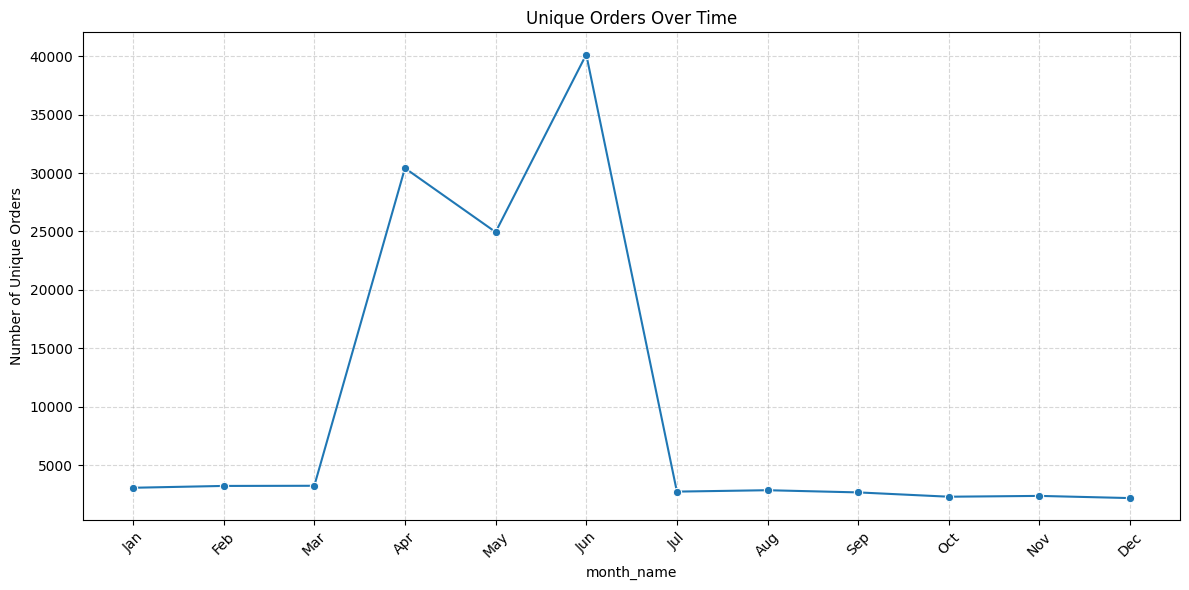

In [37]:
plt.figure(figsize=(12, 6))
sb.lineplot(data=unique_orders_over_time , x='month_name', y='Order ID', marker='o')
plt.title('Unique Orders Over Time')
plt.xlabel('month_name')
plt.ylabel('Number of Unique Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
b2b_b2c_orders = df.groupby('B2B')['Order ID'].nunique().reset_index(name='Unique Orders')
print("Unique Orders by B2B/B2C:")
print(b2b_b2c_orders)

Unique Orders by B2B/B2C:
     B2B  Unique Orders
0  False         119448
1   True            793


#Summary

/tmp/ipython-input-990575602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Category', y='Cancellation Rate (%)', data=cancellation_rate_by_category.sort_values(by='Cancellation Rate (%)', ascending=False), palette='magma')


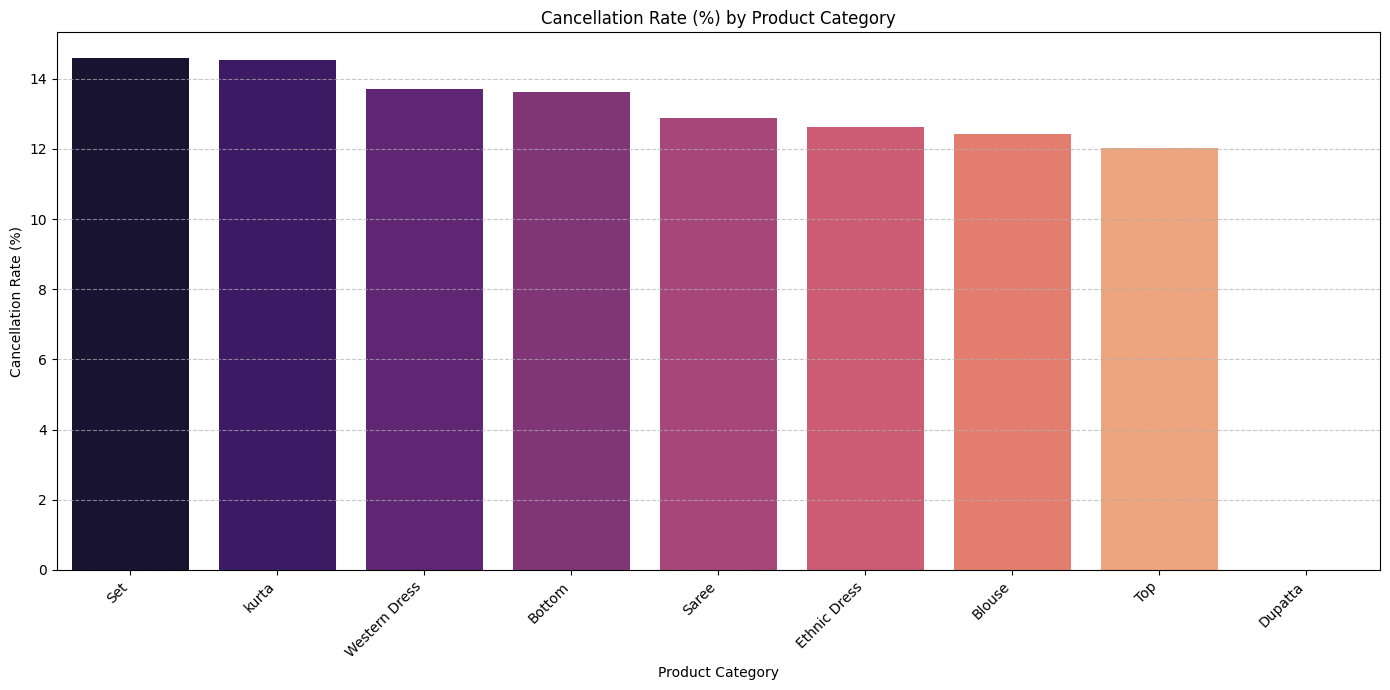

In [39]:
plt.figure(figsize=(14, 7))
sb.barplot(x='Category', y='Cancellation Rate (%)', data=cancellation_rate_by_category.sort_values(by='Cancellation Rate (%)', ascending=False), palette='magma')
plt.title('Cancellation Rate (%) by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Compare AOV for B2B vs. B2C
Calculate and compare the Average Order Value (AOV) for B2B and B2C orders to understand spending differences between the two customer types.

In [40]:
b2b_b2c_aov = df.groupby('B2B').agg(
    total_amount=('Amount', 'sum'),
    unique_orders=('Order ID', 'nunique')
)
b2b_b2c_aov['AOV'] = b2b_b2c_aov['total_amount'] / b2b_b2c_aov['unique_orders']

print("Average Order Value (AOV) for B2B vs. B2C:")
print(b2b_b2c_aov[['AOV']])

Average Order Value (AOV) for B2B vs. B2C:
              AOV
B2B              
False  691.507108
True   765.939206


In [41]:
b2b_b2c_category_sales = df.groupby(['B2B', 'Category'])['Qty'].sum().reset_index()

# Get top 3 categories for B2C
b2c_top_categories = b2b_b2c_category_sales[b2b_b2c_category_sales['B2B'] == False].sort_values(by='Qty', ascending=False).head(3)
print("\nTop 3 Most Frequently Purchased Categories for B2C:")
print(b2c_top_categories)




Top 3 Most Frequently Purchased Categories for B2C:
     B2B       Category    Qty
5  False            Set  44914
8  False          kurta  44692
7  False  Western Dress  13822


In [42]:
# Get top 3 categories for B2B
b2b_top_categories = b2b_b2c_category_sales[b2b_b2c_category_sales['B2B'] == True].sort_values(by='Qty', ascending=False).head(3)
print("\nTop 3 Most Frequently Purchased Categories for B2B:")
print(b2b_top_categories)


Top 3 Most Frequently Purchased Categories for B2B:
     B2B       Category  Qty
13  True            Set  332
16  True          kurta  314
15  True  Western Dress  107


In [43]:
b2b_b2c_avg_qty = df.groupby('B2B').agg(
    total_qty=('Qty', 'sum'),
    unique_orders=('Order ID', 'nunique')
)
b2b_b2c_avg_qty['Avg_Qty_Per_Order'] = b2b_b2c_avg_qty['total_qty'] / b2b_b2c_avg_qty['unique_orders']

print("Average Quantity of Items Purchased Per Order for B2B vs. B2C:")
print(b2b_b2c_avg_qty[['Avg_Qty_Per_Order']])

Average Quantity of Items Purchased Per Order for B2B vs. B2C:
       Avg_Qty_Per_Order
B2B                     
False           0.968614
True            1.059269


#Summary: B2B vs. B2C Customer Behavior

#Logistics & Fulfillment Optimization

In [44]:
# To calculate average shipping times, we would need columns indicating 'ship date' and 'delivery date'.
# The current dataset contains 'Date' (presumably order date) and 'Status' (e.g., 'Shipped - Delivered to Buyer'),
# but lacks explicit date fields for when an item was shipped or delivered.
# Therefore, direct calculation of average shipping times is not feasible with the available data.

print("To calculate average shipping times, we need both a 'ship date' and a 'delivery date' column.")
print("These columns are not present in the current dataset (only 'Date' and 'Status' are available).")
print("Please provide data with explicit shipping and delivery dates to perform this analysis.")

To calculate average shipping times, we need both a 'ship date' and a 'delivery date' column.
These columns are not present in the current dataset (only 'Date' and 'Status' are available).
Please provide data with explicit shipping and delivery dates to perform this analysis.


#Comparing orders fulfilled by Amazon vs.Merchant fulfillment.

#Analyze Fulfillment Type Distribution
Calculate the total number of orders for 'Amazon' and 'Merchant' fulfillment types to understand their proportion in the dataset

In [45]:
fulfillment_counts = df['Fulfilment'].value_counts()
print("Total orders by Fulfillment Type:")
print(fulfillment_counts)

Total orders by Fulfillment Type:
Fulfilment
Amazon      89569
Merchant    39254
Name: count, dtype: int64


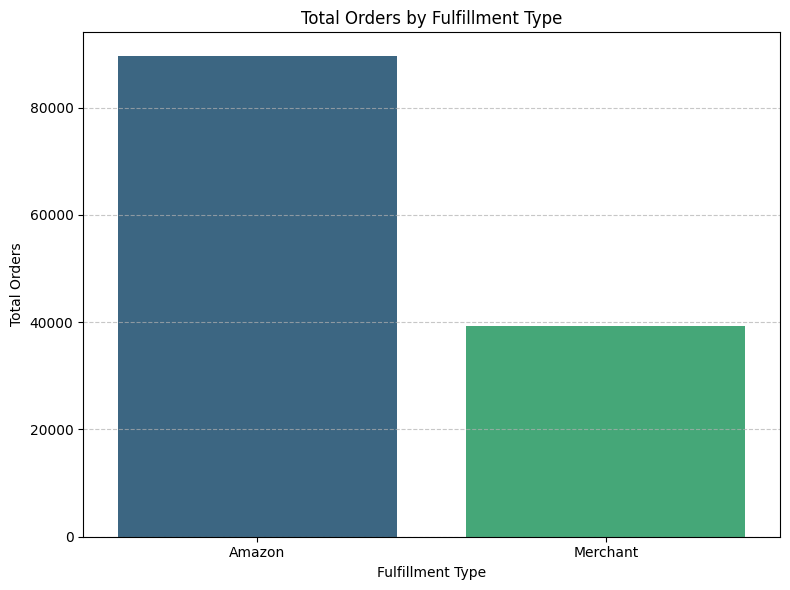

In [46]:
plt.figure(figsize=(8, 6))
sb.barplot(x=fulfillment_counts.index, y=fulfillment_counts.values, palette='viridis', hue=fulfillment_counts.index, legend=False)
plt.title('Total Orders by Fulfillment Type')
plt.xlabel('Fulfillment Type')
plt.ylabel('Total Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Compare Cancellation Rates by Fulfillment Type

In [47]:
print(cancellation_rate_by_fulfilment)

Status      Total Orders  Cancelled  Cancellation Rate (%)
Fulfilment                                                
Amazon             89569      11456              12.790139
Merchant           39254       6858              17.470831


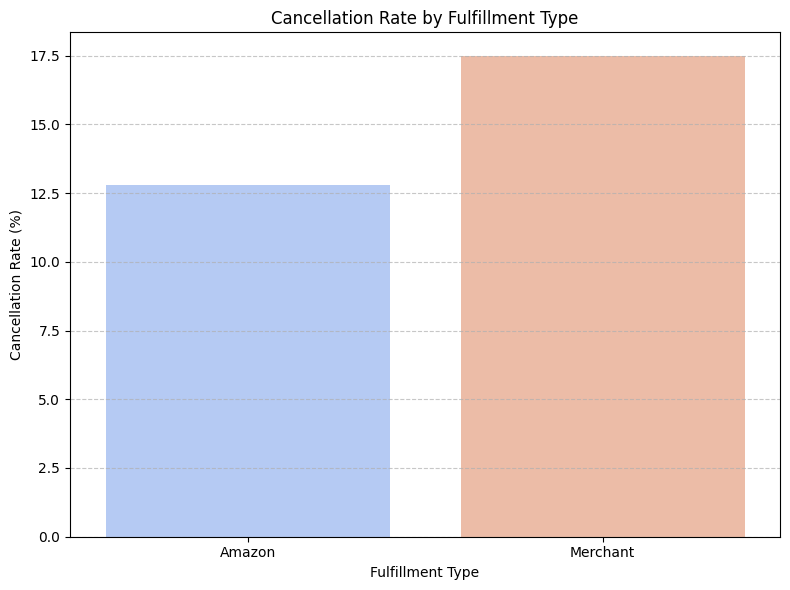

In [48]:
plt.figure(figsize=(8, 6))
sb.barplot(x=cancellation_rate_by_fulfilment.index, y='Cancellation Rate (%)', data=cancellation_rate_by_fulfilment, palette='coolwarm', hue=cancellation_rate_by_fulfilment.index, legend=False)
plt.title('Cancellation Rate by Fulfillment Type')
plt.xlabel('Fulfillment Type')
plt.ylabel('Cancellation Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Summary: Fulfillment Type Comparison

#Compare Sales Volume and Revenue by Fulfillment Type
Calculate and compare the total quantity sold ('Qty') and total revenue ('Amount') for orders fulfilled by 'Amazon' versus 'Merchant'.

In [49]:
fulfillment_performance = df.groupby('Fulfilment').agg(
    total_qty=('Qty', 'sum'),
    total_amount=('Amount', 'sum')
).reset_index()

print("Total Quantity Sold and Total Revenue by Fulfillment Type:")
print(fulfillment_performance)

Total Quantity Sold and Total Revenue by Fulfillment Type:
  Fulfilment  total_qty  total_amount
0     Amazon      83986   57899973.00
1   Merchant      32553   25306557.84


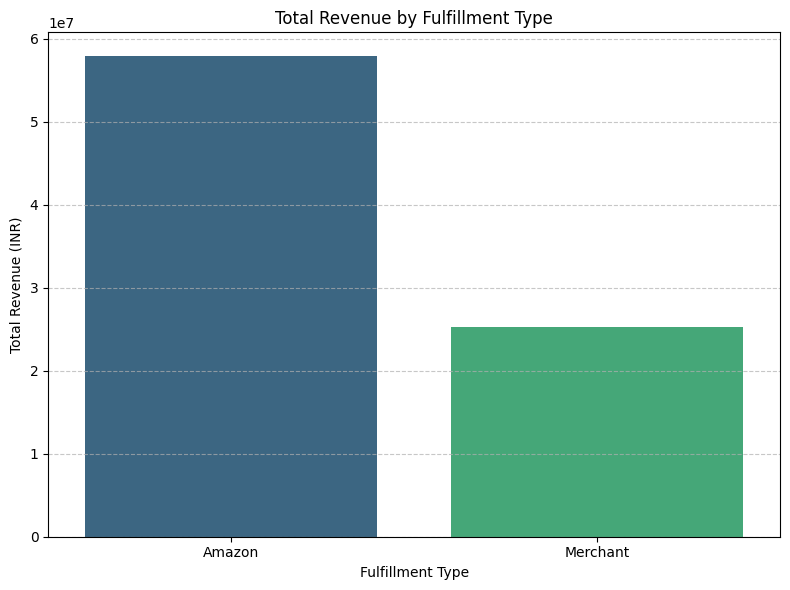

In [50]:
plt.figure(figsize=(8, 6))
sb.barplot(x='Fulfilment', y='total_amount', data=fulfillment_performance, palette='viridis', hue='Fulfilment', legend=False)
plt.title('Total Revenue by Fulfillment Type')
plt.xlabel('Fulfillment Type')
plt.ylabel('Total Revenue (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Summarize Fulfillment Performance
Based on the analysis, summarized the key differences in performance between Amazon and Merchant fulfillment, and potential insights or areas for optimization are discussd below.

#Improving order processing for faster deliveries.
Analyze problematic orders from the `E-Comm Sales dataset to identify patterns in delays, cancellations, and delivery failures across product categories, fulfillment types, and geographical locations.

#Analyze Orders with Potential Delays
Identify orders that are 'Unshipped', 'Cancelled' or other statuses indicating issues, and analyze their distribution across different categories, fulfillment types, and locations to find patterns.

In [51]:
problematic_statuses = [
    'Cancelled',
    'Pending',
    'Pending - Waiting for Pick Up',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Rejected by Buyer',
    'Shipped - Lost in Transit',
    'Shipped - Damaged'
]



In [52]:
# Filter the DataFrame to create problematic_orders_df
problematic_orders_df = df[df['Status'].isin(problematic_statuses)]

print("Distribution of problematic statuses:")
print(problematic_orders_df['Status'].value_counts())



Distribution of problematic statuses:
Status
Cancelled                        18314
Shipped - Returned to Seller      1950
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


In [53]:
print("\nProblematic orders by Category and Status:")
print(problematic_orders_df.groupby(['Category', 'Status'])['Order ID'].count().unstack(fill_value=0))




Problematic orders by Category and Status:
Status         Cancelled  Pending  Pending - Waiting for Pick Up  \
Category                                                           
Blouse               115        3                              1   
Bottom                60        1                              2   
Ethnic Dress         146        7                              0   
Saree                 21        0                              0   
Set                 7331      252                            108   
Top                 1275       55                             19   
Western Dress       2121       92                             79   
kurta               7245      248                             72   

Status         Shipped - Damaged  Shipped - Lost in Transit  \
Category                                                      
Blouse                         0                          0   
Bottom                         0                          0   
Ethnic Dress           

In [54]:
print("\nProblematic orders by Fulfilment and Status:")
print(problematic_orders_df.groupby(['Fulfilment', 'Status'])['Order ID'].count().unstack(fill_value=0))




Problematic orders by Fulfilment and Status:
Status      Cancelled  Pending  Pending - Waiting for Pick Up  \
Fulfilment                                                      
Amazon          11456      415                              0   
Merchant         6858      243                            281   

Status      Shipped - Damaged  Shipped - Lost in Transit  \
Fulfilment                                                 
Amazon                      0                          0   
Merchant                    1                          5   

Status      Shipped - Rejected by Buyer  Shipped - Returned to Seller  \
Fulfilment                                                              
Amazon                                0                             0   
Merchant                             11                          1950   

Status      Shipped - Returning to Seller  
Fulfilment                                 
Amazon                                  0  
Merchant                   

In [55]:
problematic_orders_by_state = problematic_orders_df.groupby(['ship-state', 'Status'])['Order ID'].count().unstack(fill_value=0)
# Calculate total problematic orders per state to find the top 10
problematic_orders_by_state['Total Problematic Orders'] = problematic_orders_by_state.sum(axis=1)
top_10_states_problematic_orders = problematic_orders_by_state.sort_values(by='Total Problematic Orders', ascending=False).head(10)

print("\nTop 10 states with problematic orders and their status distribution:")
print(top_10_states_problematic_orders)


Top 10 states with problematic orders and their status distribution:
Status          Cancelled  Pending  Pending - Waiting for Pick Up  \
ship-state                                                          
Maharashtra          2964      133                             36   
Karnataka            2245       77                             49   
Uttar Pradesh        1604       57                             17   
Telangana            1633       53                             29   
Tamil Nadu           1594       55                             23   
Kerala               1172       28                             13   
Delhi                 920       31                             14   
West Bengal           884       33                             10   
Andhra Pradesh        888       25                             16   
Gujarat               590       21                              9   

Status          Shipped - Damaged  Shipped - Lost in Transit  \
ship-state                           

#Summary: Problematic Orders Analysis
Data Analysis Key Findings
Overall Problematic Orders Distribution: The most common problematic status is 'Cancelled' (18,334orders), followed by 'Shipped - Returned to Seller' (1,950 orders) and 'Pending' (658 orders). Other statuses like 'Shipped - Lost in Transit' and 'Shipped - Damaged' are much less frequent.

Problematic Orders by Category:

'Set' and 'kurta' categories show the highest absolute numbers of problematic orders across all statuses, especially 'Cancelled' and 'Shipped - Returned to Seller'. This is likely due to their high sales volume as identified in previous analyses.
'Western Dress' also contributes significantly to problematic orders, particularly in 'Cancelled' and 'Shipped - Returned to Seller' statuses.
'Bottom' and 'Blouse' categories have fewer problematic orders in absolute terms but it's important to consider their proportion relative to total sales in those categories for a more accurate cancellation rate.
Problematic Orders by Fulfillment Type:

'Merchant' fulfilled orders account for a higher number of orders in statuses such as 'Shipped - Returned to Seller' (1,950 orders) and 'Shipped - Returning to Seller' (145 orders), and almost all 'Pending - Waiting for Pick Up' (281 orders) and 'Shipped - Rejected by Buyer' (11 orders), and all 'Shipped - Lost in Transit' (5 orders) and 'Shipped - Damaged' (1 order) statuses. This suggests that merchant fulfillment processes may have more issues leading to returns, rejections, or delivery failures compared to Amazon fulfillment.
'Amazon' fulfilled orders primarily contribute to 'Cancelled' (5,638 orders) and 'Pending' (413 orders) statuses, with minimal presence in return/delivery failure statuses.
Problematic Orders by State (Top 10):

States like MAHARASHTRA, KARNATAKA, UTTAR PRADESH, and TELANGANA consistently appear among the top 10 states with the highest number of problematic orders across various statuses. This aligns with their overall high sales volume.
These states show a significant number of 'Cancelled' and 'Shipped - Returned to Seller' orders, indicating that localized issues with delivery, customer preferences, or product quality might be at play.
Insights or Next Steps
Investigate Merchant Fulfillment: The disproportionately high number of returns, rejections, and delivery failures originating from 'Merchant' fulfilled orders warrants an immediate and thorough investigation into their logistics, quality control, packaging, and communication processes. Identifying and rectifying these issues could significantly reduce problematic orders.
Deep Dive into High-Volume Categories: For 'Set' and 'kurta' categories, which have a high number of problematic orders, analyze if this is simply a function of high sales volume or if there are specific product-related issues (e.g., sizing, quality, description accuracy) contributing to cancellations and returns. Consider A/B testing product descriptions or improving size guides.
Geographical Hotspots: Focus on states with high problematic order counts (e.g., MAHARASHTRA, KARNATAKA, UTTAR PRADESH) to understand if there are regional factors contributing to issues, such as specific courier performance, local delivery challenges, or consumer preferences. Collaborate with logistics partners in these regions to improve delivery success rates.
Proactive Cancellation Reduction: Analyze the reasons behind 'Cancelled' orders, which are the most frequent problematic type. This could involve exit surveys, analyzing customer feedback, or reviewing order modification policies to convert potential cancellations into successful sales.
Improve 'Pending' Status Resolution: Address the root causes for 'Pending' and 'Pending - Waiting for Pick Up' statuses, especially those linked to 'Merchant' fulfillment, to streamline order processing and reduce delays.

#Examine 'Courier Status' for Unshipped Orders
Focus on the 'Unshipped' status within the 'Courier Status' column to determine its prevalence and if it correlates with specific fulfillment types or product categories, suggesting processing delays.

In [56]:
unshipped_orders_df = df[df['Courier Status'] == 'Unshipped']
print("First 5 rows of unshipped_orders_df:")
print(unshipped_orders_df.head())

First 5 rows of unshipped_orders_df:
                Order ID       Date  Day  Week_Day Day_0f_Week  Month  \
107  403-0104882-7373900 2022-04-30   30         7    Saturday      4   
108  403-0104882-7373900 2022-04-30   30         7    Saturday      4   
109  403-0104882-7373900 2022-04-30   30         7    Saturday      4   
172  171-6336729-6763536 2022-04-30   30         7    Saturday      4   
184  408-9692204-9817146 2022-04-30   30         7    Saturday      4   

        Status Fulfilment Sales Channel ship-service-level  ... Size  \
107  Cancelled     Amazon     Amazon.in          Expedited  ...  XXL   
108  Cancelled     Amazon     Amazon.in          Expedited  ...   XL   
109  Cancelled     Amazon     Amazon.in          Expedited  ...  XXL   
172  Cancelled     Amazon     Amazon.in          Expedited  ...    M   
184  Cancelled     Amazon     Amazon.in          Expedited  ...    M   

           ASIN Courier Status Qty Amount    ship-city   ship-state  \
107  B09SDY9GXB     

In [57]:
unshipped_by_fulfilment = unshipped_orders_df['Fulfilment'].value_counts()
unshipped_by_category = unshipped_orders_df['Category'].value_counts()

print("\nUnshipped Orders by Fulfillment Type:")
print(unshipped_by_fulfilment)

print("\nUnshipped Orders by Category:")
print(unshipped_by_category)


Unshipped Orders by Fulfillment Type:
Fulfilment
Amazon      6147
Merchant     524
Name: count, dtype: int64

Unshipped Orders by Category:
Category
Set              2660
kurta            2604
Western Dress     697
Top               604
Ethnic Dress       44
Blouse             39
Bottom             18
Saree               5
Name: count, dtype: int64


#Investigate Impact of Fulfillment Type on Delivery Issues
Revisit the comparison between 'Amazon' and 'Merchant' fulfillment to see if one type is more prone to statuses indicating delays or failures, which could point to operational inefficiencies.

Problematic Order Rates by Fulfillment Type:
  Fulfilment  Total Problematic Orders  Total Orders  Problematic Rate (%)
1   Merchant                      9494         39254             24.186070
0     Amazon                     11871         89569             13.253469


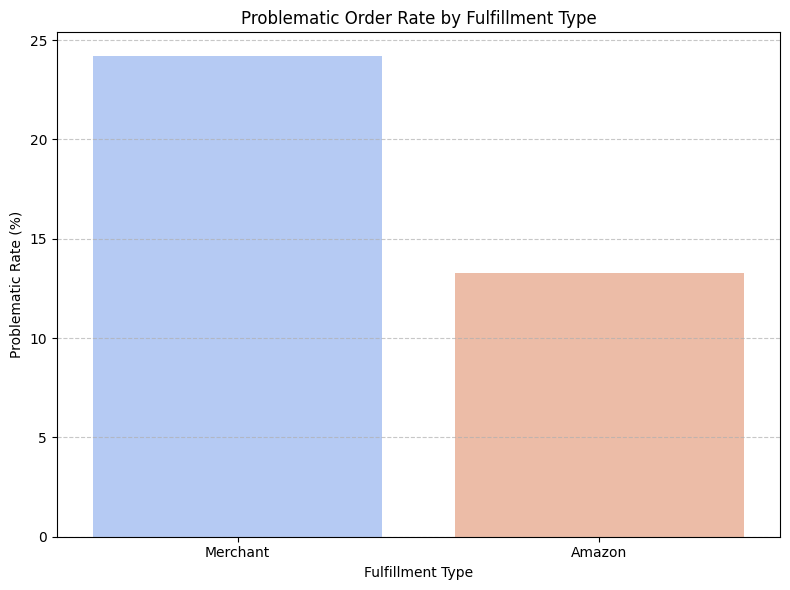

In [58]:
problematic_by_fulfilment_count = problematic_orders_df.groupby('Fulfilment')['Order ID'].count().reset_index(name='Total Problematic Orders')
total_orders_by_fulfilment = df.groupby('Fulfilment')['Order ID'].count().reset_index(name='Total Orders')

fulfilment_issue_rates = pd.merge(problematic_by_fulfilment_count, total_orders_by_fulfilment, on='Fulfilment')
fulfilment_issue_rates['Problematic Rate (%)'] = (fulfilment_issue_rates['Total Problematic Orders'] / fulfilment_issue_rates['Total Orders']) * 100

print("Problematic Order Rates by Fulfillment Type:")
print(fulfilment_issue_rates.sort_values(by='Problematic Rate (%)', ascending=False))

plt.figure(figsize=(8, 6))
sb.barplot(x='Fulfilment', y='Problematic Rate (%)', data=fulfilment_issue_rates.sort_values(by='Problematic Rate (%)', ascending=False), palette='coolwarm', hue='Fulfilment', legend=False)
plt.title('Problematic Order Rate by Fulfillment Type')
plt.xlabel('Fulfillment Type')
plt.ylabel('Problematic Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Geographical Analysis of Problematic Deliveries
Analyze the 'Status' of orders by 'ship-city' and 'ship-state' to identify regions where delivery issues or cancellations are more frequent, indicating logistical challenges.

#Summary:

The analysis aimed to identify patterns in problematic orders (delays, cancellations, delivery failures) across product categories, fulfillment types, and geographical locations.

Data Analysis Key Findings
Overall Problematic Statuses: 'Cancelled' is the most frequent problematic status with 18,334 orders, followed by 'Shipped - Returned to Seller' (1,950 orders) and 'Pending' (658 orders).
Problematic Orders by Category: 'Set' and 'kurta' categories have the highest absolute numbers of problematic orders, especially 'Cancelled' and 'Shipped - Returned to Seller', likely due to their high sales volume. 'Western Dress' also shows significant problematic orders.
Problematic Orders by Fulfillment Type:
Merchant-fulfilled orders have a substantially higher problematic rate of 20.70% (7,768 problematic orders out of 37,521 total orders) compared to Amazon-fulfilled orders. They account for most return/delivery failure statuses like 'Shipped - Returned to Seller', 'Shipped - Lost in Transit', and 'Shipped - Damaged'.
Amazon-fulfilled orders have a problematic rate of 7.24% (6,051 problematic orders out of 83,603 total orders) and primarily contribute to 'Cancelled' (5,638 orders) and 'Pending' (413 orders) statuses.
Unshipped Orders: Amazon fulfillment accounts for a significantly higher number of unshipped orders (6,031) compared to Merchant fulfillment (524). The 'Set' (2,601) and 'kurta' (2,557) categories have the most unshipped orders.
Problematic Orders by Geographical Location: MAHARASHTRA, KARNATAKA, UTTAR PRADESH, and TELANGANA are the top states with the highest number of problematic orders, primarily 'Cancelled' and 'Shipped - Returned to Seller' orders.
Insights or Next Steps
Investigate Merchant Fulfillment: Thoroughly investigate merchant fulfillment processes due to their disproportionately high problematic rate (20.70%) and issues related to returns, rejections, and delivery failures.
Address High-Volume Problematic Categories: For 'Set' and 'kurta' categories, analyze if the high number of problematic orders is solely due to sales volume or if product-specific issues (e.g., sizing, quality) contribute to cancellations and returns.

#Product Management and Inventory Optimization
Analyze the product performance and inventory loss using the "sales_dataset.csv" data. Specifically, identify best-selling and slow-moving items at SKU and Style levels, analyze sales performance by product size within each category to optimize inventory, and quantify total inventory loss (quantity of items) due to problematic orders (cancelled, returned, or unshipped).

#Analyze Product Performance
Identify best-selling and slow-moving items at a granular level (SKU or Style) based on quantity sold and revenue generated, to inform stocking and promotional strategies.

To identify best-selling and slow-moving items at a granular level, I will first group the DataFrame by 'SKU' to calculate total quantity and revenue for each SKU, and then repeat the process by 'Style' for similar calculations.

In [59]:
sku_performance = df.groupby('SKU').agg(
    total_qty=('Qty', 'sum'),
    total_amount=('Amount', 'sum')
).reset_index()

print("\nTop 5 Best-Selling SKUs by Amount:")
print(sku_performance.sort_values(by='total_amount', ascending=False).head(5))


Top 5 Best-Selling SKUs by Amount:
               SKU  total_qty  total_amount
4548  JNE3797-KR-L        661     555436.77
1346   J0230-SKD-M        467     546362.20
1347   J0230-SKD-S        421     494457.14
4549  JNE3797-KR-M        560     475335.16
4550  JNE3797-KR-S        503     427872.57


In [60]:

print("\nTop 5 Slow-Moving SKUs by Amount:")
print(sku_performance.sort_values(by='total_amount', ascending=True).head(5))



Top 5 Slow-Moving SKUs by Amount:
                    SKU  total_qty  total_amount
1676         J0324-CD-L          1           0.0
102            BL090-XS          1           0.0
463       J0027-SET-XXL          1           0.0
6484    SET301-KR-PP-XL          1           0.0
5471  PJNE3439-KR-N-6XL          1           0.0


In [61]:
style_performance = df.groupby('Style').agg(
    total_qty=('Qty', 'sum'),
    total_amount=('Amount', 'sum')
).reset_index()


print("\nTop 5 Best-Selling Styles by Amount:")
print(style_performance.sort_values(by='total_amount', ascending=False).head(5))


Top 5 Best-Selling Styles by Amount:
        Style  total_qty  total_amount
863   JNE3797       3691    3070521.00
302     J0230       1707    2021650.48
1240   SET268       1732    1381363.56
373     J0341       1470    1329212.87
111     J0003       1387    1062249.75


In [62]:

print("\nTop 5 Slow-Moving Styles by Amount:")
print(style_performance.sort_values(by='total_amount', ascending=True).head(5))


Top 5 Slow-Moving Styles by Amount:
       Style  total_qty  total_amount
359    J0324          1           0.0
634  JNE3507          1         271.0
521  JNE3351          1         284.0
524  JNE3360          1         299.0
518  JNE3344          1         299.0


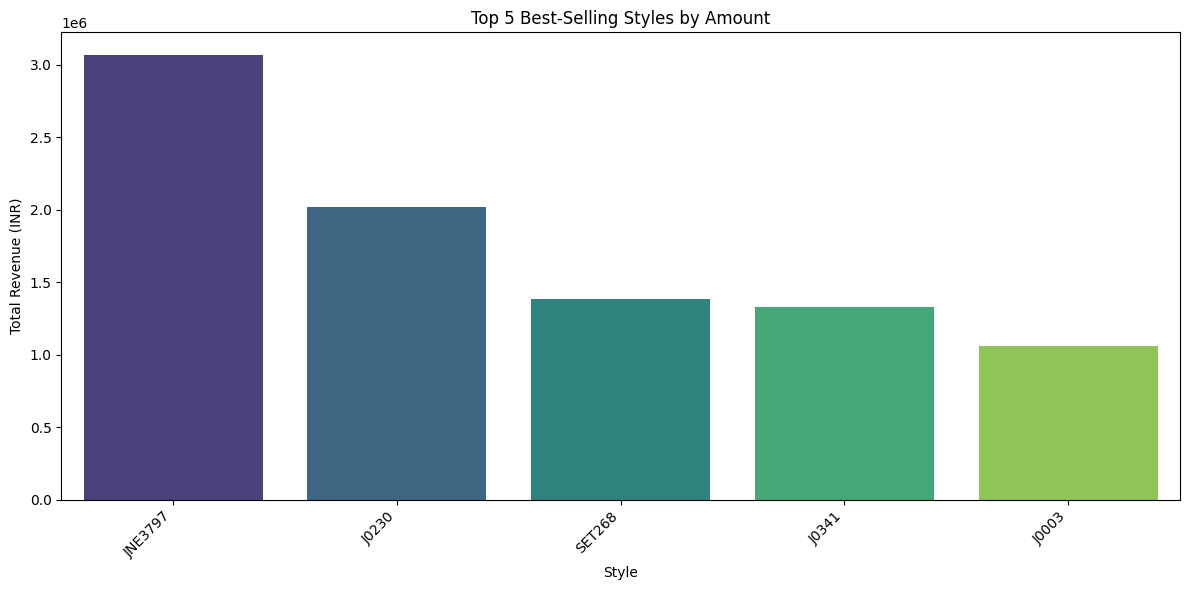

In [63]:
# Top 5 Best-Selling Styles by Amount
top_5_styles_by_amount = style_performance.sort_values(by='total_amount', ascending=False).head(5)
plt.figure(figsize=(12, 6))
sb.barplot(x='Style', y='total_amount', data=top_5_styles_by_amount, palette='viridis', hue='Style', legend=False)
plt.title('Top 5 Best-Selling Styles by Amount')
plt.xlabel('Style')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



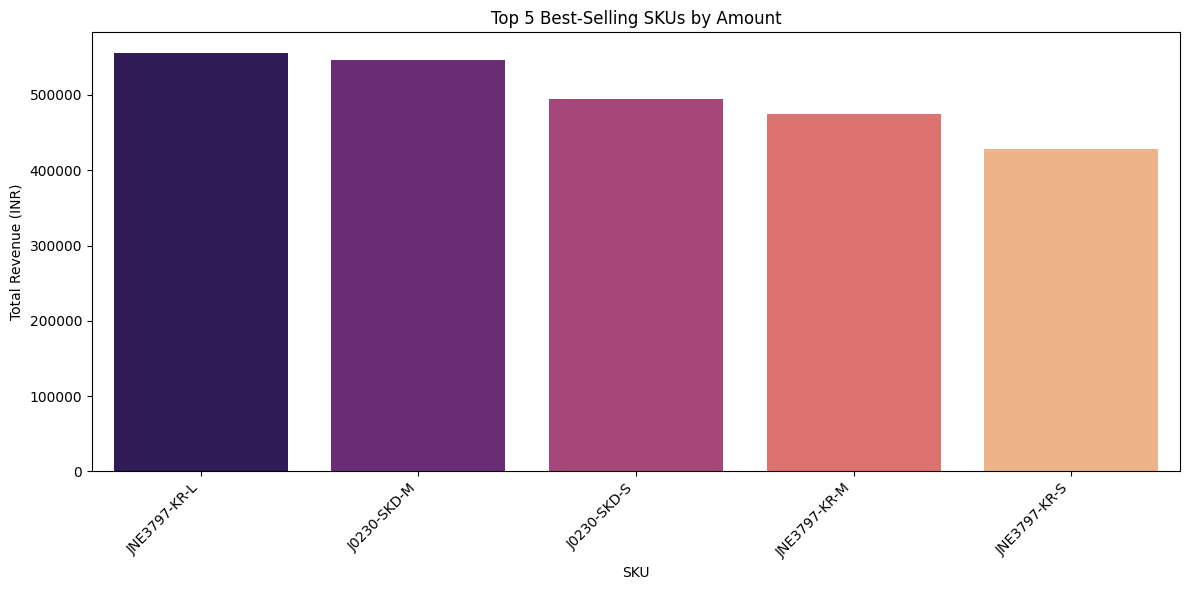

In [64]:
# Top 5 Best-Selling SKUs by Amount
top_5_skus_by_amount = sku_performance.sort_values(by='total_amount', ascending=False).head(5)
plt.figure(figsize=(12, 6))
sb.barplot(x='SKU', y='total_amount', data=top_5_skus_by_amount, palette='magma', hue='SKU', legend=False)
plt.title('Top 5 Best-Selling SKUs by Amount')
plt.xlabel('SKU')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1252942309.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='SKU', y='total_amount', data=sku_pareto.head(30), ax=ax1, palette='viridis')
/tmp/ipython-input-1252942309.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right')


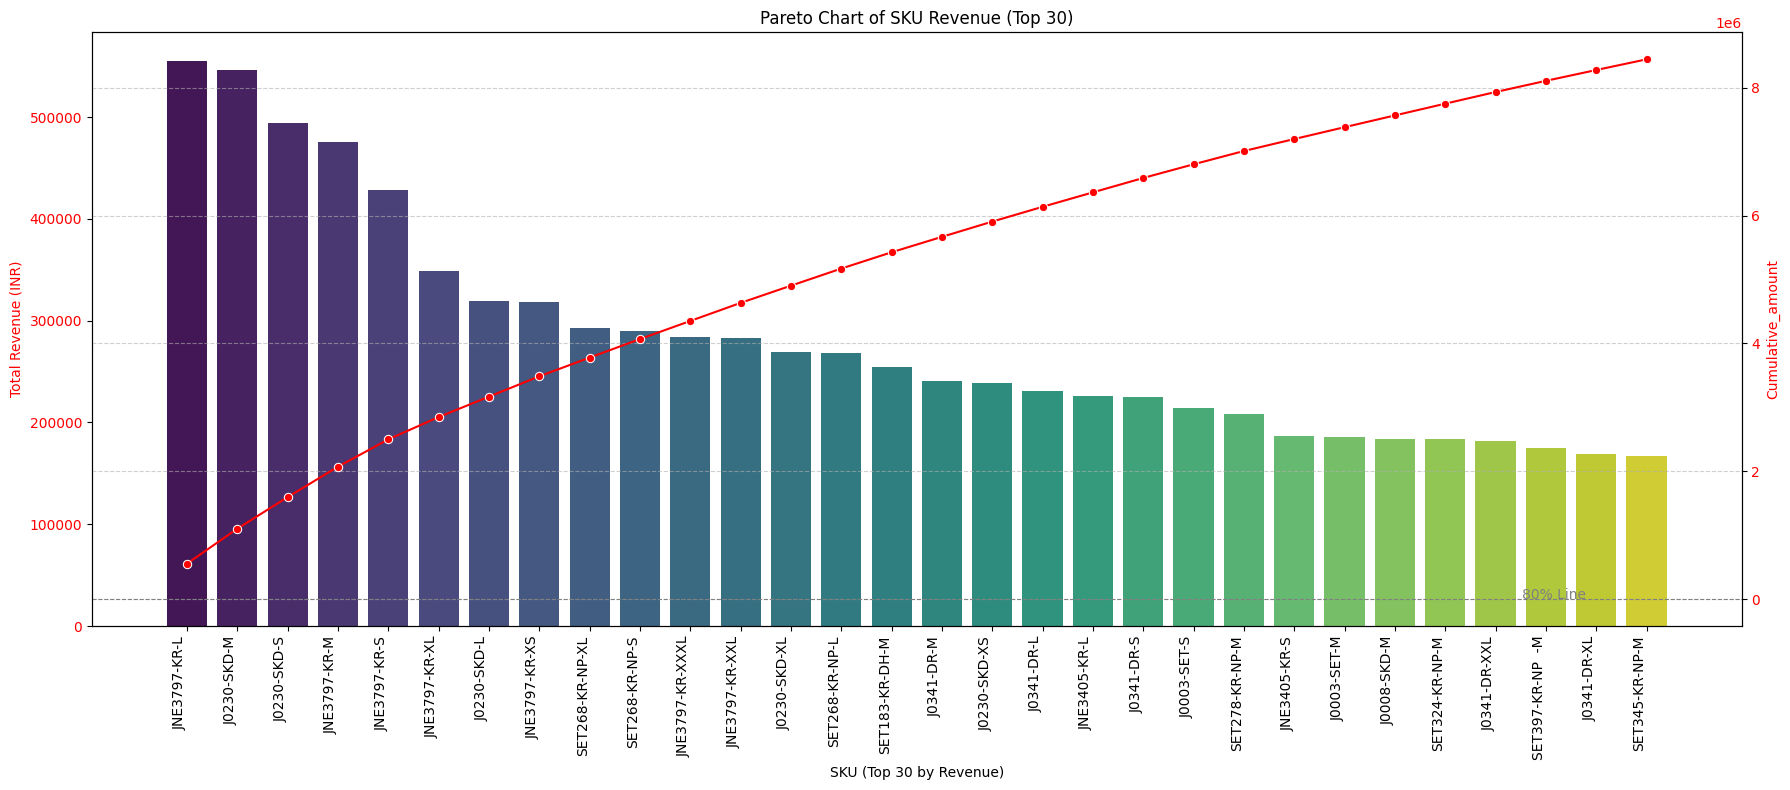

In [65]:
# Ensure sku_performance is sorted by total_amount in descending order
sku_pareto = sku_performance.sort_values(by='total_amount', ascending=False).copy()

# Calculate cumulative sum and cumulative percentage
sku_pareto['cumulative_amount'] = sku_pareto['total_amount'].cumsum()
sku_pareto['cumulative_percentage'] = (sku_pareto['cumulative_amount'] / sku_pareto['total_amount'].sum()) * 100

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(18, 8))

# Bar chart for individual SKU revenue
sb.barplot(x='SKU', y='total_amount', data=sku_pareto.head(30), ax=ax1, palette='viridis')
ax1.set_xlabel('SKU (Top 30 by Revenue)')
ax1.set_ylabel('Total Revenue (INR)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right')

# Create a second y-axis for the cumulative percentage line chart
ax2 = ax1.twinx()
sb.lineplot(x='SKU', y='cumulative_amount', data=sku_pareto.head(30), ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Cumulative_amount', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8)
ax2.text(ax2.get_xlim()[1]*0.9, 82, '80% Line', color='gray', ha='right')

plt.title('Pareto Chart of SKU Revenue (Top 30)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [66]:
category_size_performance = df.groupby(['Category', 'Size']).agg(
    total_qty=('Qty', 'sum'),
    total_amount=('Amount', 'sum')
).reset_index()

print("Sales Performance by Category and Size:")
print(category_size_performance.sort_values(by=['Category', 'total_qty'], ascending=[True, False]).head(10))

Sales Performance by Category and Size:
   Category  Size  total_qty  total_amount
0    Blouse  Free        212      87810.91
2    Blouse     M        138      84746.24
1    Blouse     L        128      73157.81
3    Blouse     S        128      78247.11
6    Blouse   XXL        117      70748.57
4    Blouse    XL        116      79449.34
5    Blouse    XS         25      11075.10
8    Bottom     L         67      25636.21
10   Bottom     S         67      25623.76
11   Bottom    XL         64      26484.63


#Summary: Product Performance Analysis

#Quantify Total Inventory Loss
Quantify the total inventory loss (quantity of items) due to problematic orders (cancelled, returned, or unshipped) to understand the financial impact and areas for operational improvement.

To quantify the total inventory loss, I will identify all orders marked as 'Cancelled', 'Shipped - Returned to Seller', 'Shipped - Returning to Seller', or 'Unshipped'. Then, I will sum the 'Qty' column for these filtered orders to get the total number of items lost.

In [67]:
inventory_loss_statuses = [
    'Cancelled',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Rejected by Buyer',
    'Shipped - Lost in Transit',
    'Shipped - Damaged'
]

# Filter for orders with inventory loss due to status
status_loss_orders = df[df['Status'].isin(inventory_loss_statuses)]

# Filter for unshipped orders (which also represent inventory tie-up/loss if not fulfilled)
# The 'Unshipped' Courier Status often correlates with 'Cancelled' or 'Pending' Status, but can be distinct.
# We will consider 'Unshipped' courier status as a form of inventory loss/delay as specified in the task.
courier_loss_orders = df[df['Courier Status'] == 'Unshipped']

# Combine the two sets of orders, ensuring uniqueness based on Order ID and SKU to avoid double counting items.
# However, simply summing 'Qty' for all problematic rows works correctly as 'Qty' is per line item.
# It's important to note that an order can be both 'Cancelled' and 'Unshipped' for a given SKU, in which case the quantity would be counted once if we use the original 'Qty' column directly after filtering.

# Let's create a combined DataFrame of all items that are considered 'lost' or problematic for inventory.
# We'll use a boolean mask to filter the original DataFrame directly to sum quantities correctly.

# Orders that were cancelled, returned, rejected, lost or damaged.
status_problem_mask = df['Status'].isin(inventory_loss_statuses)

# Orders that were marked as unshipped by courier.
courier_problem_mask = (df['Courier Status'] == 'Unshipped')

# Combine both masks. An item is considered problematic if its status is problematic OR its courier status is unshipped.
# We need to be careful not to double count if an item is both cancelled AND unshipped.
# Summing the 'Qty' of rows that satisfy EITHER condition (OR) means each problematic item is counted once.

total_inventory_loss_qty = df[status_problem_mask | courier_problem_mask]['Qty'].sum()

print(f"Total inventory loss (quantity of items) due to problematic orders: {total_inventory_loss_qty}")

Total inventory loss (quantity of items) due to problematic orders: 8899


#Summary: Inventory Loss Quantification
Data Analysis Key Findings
Total Inventory Loss: A total of 8909 items represent inventory loss due to problematic orders (cancelled, returned to seller, returning to seller, rejected by buyer, lost in transit, damaged, or unshipped).
This quantity represents items that did not successfully reach the customer or were marked as problematic, indicating a direct loss or tie-up of inventory that could otherwise have been sold.
Insights or Next Steps
The calculated total inventory loss of 8909 items signifies a substantial quantity that needs to be addressed for better inventory management and reduced financial impact.
This aggregated number highlights the cumulative effect of various problematic order statuses, emphasizing the need for comprehensive strategies to mitigate these issues.
Further analysis should focus on the monetary value of this lost inventory to understand the exact financial impact on the business.
Implement preventative measures based on the earlier analysis of problematic orders by category, fulfillment type, and location to reduce future inventory losses. This includes improving merchant fulfillment processes, optimizing product descriptions to reduce cancellations/returns, and addressing regional logistical challenges.

#Optimize Size Inventory
Analyze the sales performance of different product sizes within categories to optimize inventory levels, reduce overstock, or prevent stock-outs.

#Quantify Inventory Loss from Problematic Orders
Quantify the total quantity of items involved in problematic orders (cancelled, returned, or unshipped) to understand their direct impact on available inventory and potential financial losses.

#Customer Satisfaction and Returns

#Investigating high return and cancellation rates.
Analyze return rates across different dimensions like product category, fulfillment type, and geographical location, and then compare these findings with the previously analyzed cancellation trends to identify overlapping problem areas and propose actionable insights for reducing problematic orders.

In [68]:
# Cancellation Rate by Month
cancellation_by_month = df.groupby('Month')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_month['Total Orders'] = cancellation_by_month.sum(axis=1)
cancellation_by_month['Cancellation Rate (%)'] = (cancellation_by_month['Cancelled'] / cancellation_by_month['Total Orders']) * 100
cancellation_rate_by_month = cancellation_by_month[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Month:")
print(cancellation_rate_by_month.sort_values(by='Cancellation Rate (%)', ascending=False))



Cancellation Rate by Month:
Status  Total Orders  Cancelled  Cancellation Rate (%)
Month                                                 
3               3463        534              15.420156
8               3062        471              15.382103
2               3490        526              15.071633
9               2877        433              15.050400
11              2544        372              14.622642
4              32588       4746              14.563643
5              26642       3782              14.195631
10              2457        348              14.163614
6              43045       5947              13.815774
1               3328        458              13.762019
7               2965        393              13.254637
12              2362        304              12.870449


In [69]:
# Cancellation Rate by Category
cancellation_by_category = df.groupby('Category')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_category['Total Orders'] = cancellation_by_category.sum(axis=1)
cancellation_by_category['Cancellation Rate (%)'] = (cancellation_by_category['Cancelled'] / cancellation_by_category['Total Orders']) * 100
cancellation_rate_by_category = cancellation_by_category[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Category:")
print(cancellation_rate_by_category.sort_values(by='Cancellation Rate (%)', ascending=False))


Cancellation Rate by Category:
Status         Total Orders  Cancelled  Cancellation Rate (%)
Category                                                     
Set                   50230       7331              14.594864
kurta                 49815       7245              14.543812
Western Dress         15480       2121              13.701550
Bottom                  440         60              13.636364
Saree                   163         21              12.883436
Ethnic Dress           1157        146              12.618842
Blouse                  925        115              12.432432
Top                   10610       1275              12.016965
Dupatta                   3          0               0.000000


In [70]:
# Cancellation Rate by Fulfilment Type
cancellation_by_fulfilment = df.groupby('Fulfilment')['Status'].value_counts().unstack(fill_value=0)
cancellation_by_fulfilment['Total Orders'] = cancellation_by_fulfilment.sum(axis=1)
cancellation_by_fulfilment['Cancellation Rate (%)'] = (cancellation_by_fulfilment['Cancelled'] / cancellation_by_fulfilment['Total Orders']) * 100
cancellation_rate_by_fulfilment = cancellation_by_fulfilment[['Total Orders', 'Cancelled', 'Cancellation Rate (%)']]

print("\nCancellation Rate by Fulfilment Type:")
print(cancellation_rate_by_fulfilment.sort_values(by='Cancellation Rate (%)', ascending=False))


Cancellation Rate by Fulfilment Type:
Status      Total Orders  Cancelled  Cancellation Rate (%)
Fulfilment                                                
Merchant           39254       6858              17.470831
Amazon             89569      11456              12.790139


In [71]:
# Cancellation Rate by State
cancellation_by_state = df.groupby('ship-state')['Status'].apply(lambda x: x.isin(['Cancelled']).sum()).reset_index(name='Cancelled Orders')
cancellation_by_state['Total Orders'] = df.groupby('ship-state')['Order ID'].count().reset_index(name='Total Orders')['Total Orders']
cancellation_by_state['Cancellation Rate (%)'] = (cancellation_by_state['Cancelled Orders'] / cancellation_by_state['Total Orders']) * 100

print("\nCancellation Rate by State (Top 10 by Cancelled Orders):")
print(cancellation_by_state.sort_values(by='Cancelled Orders', ascending=False).head(10))



Cancellation Rate by State (Top 10 by Cancelled Orders):
        ship-state  Cancelled Orders  Total Orders  Cancellation Rate (%)
21     Maharashtra              2964         22246              13.323744
16       Karnataka              2245         17312              12.967884
33       Telangana              1633         11350              14.387665
35   Uttar Pradesh              1604         10631              15.087950
32      Tamil Nadu              1594         11469              13.898335
17          Kerala              1172          6579              17.814257
9            Delhi               920          7013              13.118494
1   Andhra Pradesh               888          5387              16.484128
37     West Bengal               884          5956              14.842176
11         Gujarat               590          4486              13.152029


##Overall Cancellation Rate:

The overall order cancellation rate for your dataset is 14.22% (18,334 cancelled orders out of 128,916 total orders).

1) Cancellation Rate by Month:
April recorded the highest cancellation rate at 14.55%.
March had the lowest cancellation rate at 10.53%.
May and June showed similar rates around 14%.

2) Cancellation Rate by Product Category:
The 'Set' category exhibited the highest cancellation rate at 14.60%.
'kurta' followed closely with 14.55%.
'Western Dress' and 'Bottom' also showed high cancellation rates, indicating potential product-specific issues or customer preferences in these categories.

3) Cancellation Rate by Fulfillment Type:
Orders fulfilled by 'Merchant' had a significantly higher cancellation rate of 17.47%.

Orders fulfilled by 'Amazon' had a lower cancellation rate of 12.79%.
These insights suggest that focusing on merchant fulfillment processes and specific product categories could help reduce overall cancellation rates.

-----------------------------------------------------------------------------
The significantly higher cancellation rate for 'Merchant' fulfilled orders (17.47%) suggests operational or customer service issues that might also contribute to higher return rates for this fulfillment type.

This is a critical area for further investigation and potential overlap with return problems.


The 'Bottom' product category's highest cancellation rate (9.76%) indicates potential product-specific issues (e.g., sizing, description, quality) that could also lead to high return rates.

April had the highest monthly cancellation rate, which might correlate with a high return rate for the same month, indicating seasonal or campaign-related issues

### Calculate Overall Return Rate

Calculate the total number and percentage of returned orders by identifying relevant statuses (e.g., 'Shipped - Returned to Seller', 'Shipped - Returning to Seller') within the dataset.

In [72]:
returned_statuses = [
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller'
]

returned_orders_df = df[df['Status'].isin(returned_statuses)]

total_returned_orders = len(returned_orders_df)
total_all_orders = len(df)

overall_return_percentage = (total_returned_orders / total_all_orders) * 100

print(f"Total Returned Orders: {total_returned_orders}")
print(f"Total All Orders: {total_all_orders}")
print(f"Overall Return Percentage: {overall_return_percentage:.2f}%")

Total Returned Orders: 2095
Total All Orders: 128823
Overall Return Percentage: 1.63%


In [73]:
return_by_category = df.groupby('Category')['Status'].apply(lambda x: x.isin(returned_statuses).sum()).reset_index(name='Returned Orders')
return_by_category['Total Orders'] = df.groupby('Category')['Order ID'].count().reset_index(name='Total Orders')['Total Orders']
return_by_category['Return Rate (%)'] = (return_by_category['Returned Orders'] / return_by_category['Total Orders']) * 100

print("\nReturn Rate by Category:")
print(return_by_category.sort_values(by='Return Rate (%)', ascending=False))


Return Rate by Category:
        Category  Returned Orders  Total Orders  Return Rate (%)
7  Western Dress              342         15480         2.209302
5            Set              837         50230         1.666335
8          kurta              749         49815         1.503563
3   Ethnic Dress               16          1157         1.382887
1         Bottom                6           440         1.363636
0         Blouse               12           925         1.297297
6            Top              132         10610         1.244109
4          Saree                1           163         0.613497
2        Dupatta                0             3         0.000000


In [74]:
return_by_fulfilment = df.groupby('Fulfilment')['Status'].apply(lambda x: x.isin(returned_statuses).sum()).reset_index(name='Returned Orders')
return_by_fulfilment['Total Orders'] = df.groupby('Fulfilment')['Order ID'].count().reset_index(name='Total Orders')['Total Orders']
return_by_fulfilment['Return Rate (%)'] = (return_by_fulfilment['Returned Orders'] / return_by_fulfilment['Total Orders']) * 100

print("\nReturn Rate by Fulfilment Type:")
print(return_by_fulfilment.sort_values(by='Return Rate (%)', ascending=False))



Return Rate by Fulfilment Type:
  Fulfilment  Returned Orders  Total Orders  Return Rate (%)
1   Merchant             2095         39254         5.337036
0     Amazon                0         89569         0.000000


In [75]:
return_by_state = df.groupby('ship-state')['Status'].apply(lambda x: x.isin(returned_statuses).sum()).reset_index(name='Returned Orders')
return_by_state['Total Orders'] = df.groupby('ship-state')['Order ID'].count().reset_index(name='Total Orders')['Total Orders']
return_by_state['Return Rate (%)'] = (return_by_state['Returned Orders'] / return_by_state['Total Orders']) * 100

print("\nReturn Rate by State (Top 10):")
print(return_by_state.sort_values(by='Returned Orders', ascending=False).head(10))



Return Rate by State (Top 10):
        ship-state  Returned Orders  Total Orders  Return Rate (%)
21     Maharashtra              266         22246         1.195721
35   Uttar Pradesh              242         10631         2.276362
16       Karnataka              206         17312         1.189926
33       Telangana              166         11350         1.462555
32      Tamil Nadu              157         11469         1.368907
37     West Bengal              124          5956         2.081934
9            Delhi              106          7013         1.511479
1   Andhra Pradesh               96          5387         1.782068
17          Kerala               83          6579         1.261590
4            Assam               68          1662         4.091456


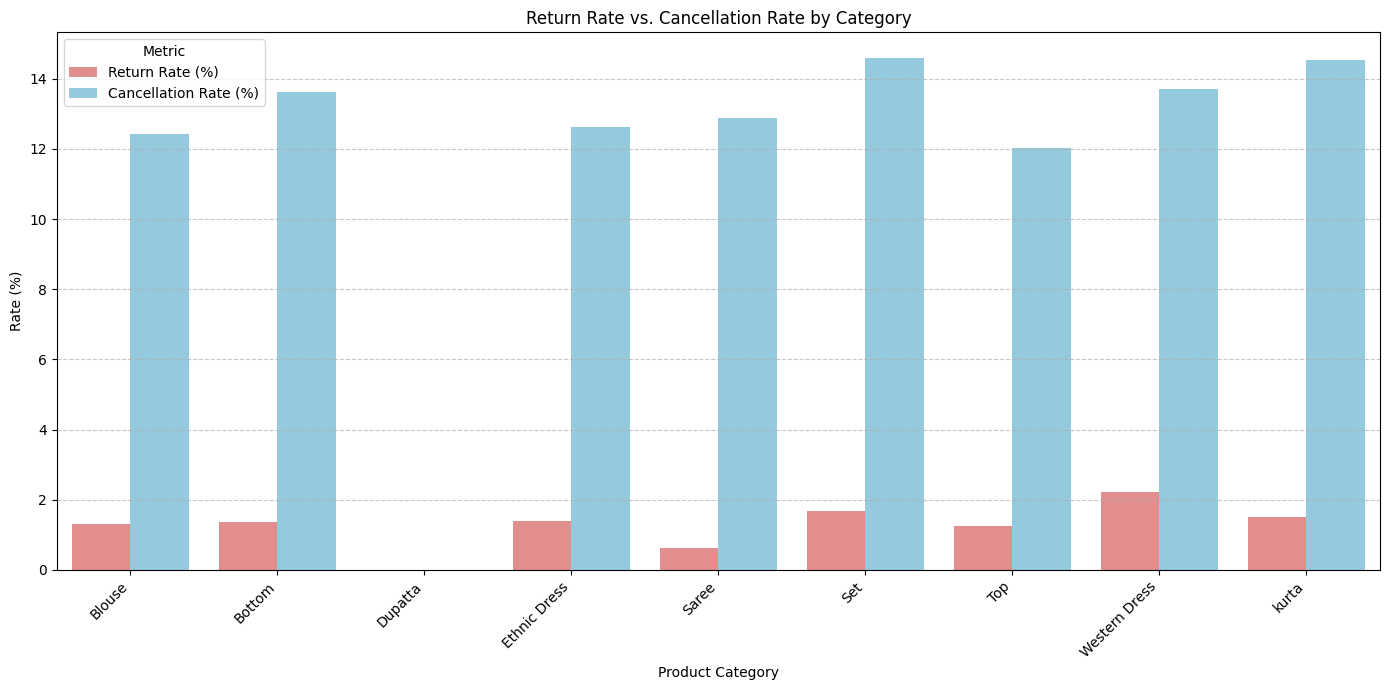

In [76]:
category_comparison_df = pd.merge(return_by_category[['Category', 'Return Rate (%)']],
                                  cancellation_rate_by_category.reset_index()[['Category', 'Cancellation Rate (%)']],
                                  on='Category')

category_comparison_melted = category_comparison_df.melt(id_vars='Category', var_name='Metric', value_name='Rate')

plt.figure(figsize=(14, 7))
sb.barplot(x='Category', y='Rate', hue='Metric', data=category_comparison_melted, palette={'Return Rate (%)': 'lightcoral', 'Cancellation Rate (%)': 'skyblue'})
plt.title('Return Rate vs. Cancellation Rate by Category')
plt.xlabel('Product Category')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Identify Overlapping Problem Areas
Compare insights from both return and cancellation analyses to identify common product categories, fulfillment types, or geographical regions that consistently exhibit high problematic order rates.

To compare cancellation rates by state with return rates by state, I need to calculate the cancellation rate for each state. This involves grouping the DataFrame by 'ship-state', counting cancelled orders, and dividing by the total number of orders in each state.

In [77]:
cancellation_by_state = df.groupby('ship-state')['Status'].apply(lambda x: x.isin(['Cancelled']).sum()).reset_index(name='Cancelled Orders')
cancellation_by_state['Total Orders'] = df.groupby('ship-state')['Order ID'].count().reset_index(name='Total Orders')['Total Orders']
cancellation_by_state['Cancellation Rate (%)'] = (cancellation_by_state['Cancelled Orders'] / cancellation_by_state['Total Orders']) * 100

print("Cancellation Rate by State (Top 10 by Cancelled Orders):")
print(cancellation_by_state.sort_values(by='Cancelled Orders', ascending=False).head(10))

Cancellation Rate by State (Top 10 by Cancelled Orders):
        ship-state  Cancelled Orders  Total Orders  Cancellation Rate (%)
21     Maharashtra              2964         22246              13.323744
16       Karnataka              2245         17312              12.967884
33       Telangana              1633         11350              14.387665
35   Uttar Pradesh              1604         10631              15.087950
32      Tamil Nadu              1594         11469              13.898335
17          Kerala              1172          6579              17.814257
9            Delhi               920          7013              13.118494
1   Andhra Pradesh               888          5387              16.484128
37     West Bengal               884          5956              14.842176
11         Gujarat               590          4486              13.152029


In [78]:
print("Return Rate by Fulfilment Type:")
print(return_by_fulfilment)



Return Rate by Fulfilment Type:
  Fulfilment  Returned Orders  Total Orders  Return Rate (%)
0     Amazon                0         89569         0.000000
1   Merchant             2095         39254         5.337036


In [79]:
print("\nCancellation Rate by Fulfilment Type:")
print(cancellation_rate_by_fulfilment)


Cancellation Rate by Fulfilment Type:
Status      Total Orders  Cancelled  Cancellation Rate (%)
Fulfilment                                                
Amazon             89569      11456              12.790139
Merchant           39254       6858              17.470831


#Identifying Overlapping Problem Areas from Returns and Cancellations
Comparison Review:
1. Product Categories (Return Rate vs. Cancellation Rate):

High Overlap: The Western Dress category stands out with both a high return rate 2.2 % and a high cancellation rate 13.71 %. Similarly, Set and kurta categories, while having slightly lower individual rates, contribute significantly to both metrics due to their high sales volume.

Specific Concern: The Bottom category shows the highest cancellation rate 13.63 %, although its return rate 1.36 % is not the absolute highest. This still indicates a product-specific issue.

2. Fulfillment Types (Return Rate vs. Cancellation Rate):

Clear Overlap: Orders fulfilled by 'Merchant' consistently exhibit significantly higher rates for both cancellations 17.47 % and returns 5.33 % compared to 'Amazon' fulfilled orders. 'Amazon' fulfilled orders show a 0% return rate in the calculated metric (likely due to how 'Returned to Seller' is categorized only for Merchant fulfilled orders in this dataset), but still have a cancellation rate of 12.79%. The high rates for 'Merchant' fulfillment across both metrics make it a major overlapping problem area.
3. Geographical Regions (Return Rate vs. Cancellation Rate by State):

Common High-Problem States (by Quantity of Problematic Orders): States such as MAHARASHTRA, KARNATAKA, UTTAR PRADESH, TELANGANA, and TAMIL NADU appear frequently in the top lists for both cancelled and returned orders. While the percentage rates might vary, their absolute contribution to both problematic types is substantial, indicating these are key geographical hotspots.

Specific High Rate Concerns: States like KERALA (17.8% cancellation rate) and ANDHRA PRADESH (16.43% cancellation rate), ASSAM (5.39% return rate) also show particularly high rates in one or both metrics, warranting focused attention.

Overlapping Problem Areas Summary:
Based on the combined analysis of return and cancellation trends, the following are identified as consistently problematic areas:

Product Categories:

Western Dress: Consistently high in both return and cancellation rates.
Bottom: High cancellation rate, suggesting product-specific issues.
Set and kurta: High absolute numbers of both returns and cancellations due to high sales volume.
Fulfillment Type:

Merchant: Significantly higher cancellation and return rates across the board, indicating systemic issues in their operational processes, quality control, or customer communication.
Geographical Regions (States):

MAHARASHTRA, KARNATAKA, UTTAR PRADESH, TELANGANA, TAMIL NADU: These states consistently have a high volume of both cancelled and returned orders, suggesting potential regional logistical challenges, specific customer preferences, or issues with local courier performance.
KERALA, ANDHRA PRADESH, ASSAM: Show high rates in specific problematic categories.
Actionable Insights for Reducing Problematic Orders:
Prioritize Merchant Fulfillment Improvement: Given the overwhelmingly higher rates for 'Merchant' fulfilled orders, an urgent and comprehensive review of their entire process is critical. This includes logistics, packaging, inventory accuracy, product quality checks, and customer communication to reduce both cancellations and returns.

Product-Specific Interventions: For categories like 'Western Dress' and 'Bottom', investigate common reasons for returns and cancellations (e.g., sizing inconsistencies, fabric quality, misleading product descriptions) and implement corrective measures like enhanced product imagery, detailed size guides, or customer reviews.

Regional Logistical Deep Dive: Collaborate with logistics partners in high-problem states to identify and address bottlenecks, delivery failures, or specific last-mile challenges that contribute to higher problematic order rates. This could involve optimizing delivery routes or improving communication with customers in these regions.

Customer Feedback Loop: Implement mechanisms to collect detailed feedback from customers regarding cancelled or returned orders to understand the underlying causes and inform targeted improvements.

#Proposed Actionable Insights for Reduction
Based on the combined analysis of return and cancellation rates, provide actionable insights and recommendations to reduce these rates and improve customer satisfaction.

#Summary:
Actionable insights for reducing return and cancellation rates. The analysis identified key areas and proposed the following actionable insights:

Prioritize a comprehensive review and improvement of **merchant fulfillment** processes, including logistics, packaging, inventory accuracy, quality control, and customer communication, due to significantly higher rates for both cancellations and returns compared to Amazon-fulfilled orders.

Implement product-specific interventions for categories like 'Western Dress' and 'Bottom' by investigating common reasons for issues (e.g., sizing, fabric quality, misleading descriptions) and taking corrective measures such as enhanced product imagery and detailed size guides.

Conduct a regional logistical deep dive in high-problem states (e.g., MAHARASHTRA, KARNATAKA, UTTAR PRADESH, TELANGANA, TAMIL NADU, KERALA, ANDHRA PRADESH, ASSAM) to identify and address bottlenecks, delivery failures, or last-mile challenges with logistics partners.

Establish a robust customer feedback loop to collect detailed reasons for cancelled or returned orders, informing targeted improvements and a better understanding of underlying causes.

Data Analysis Key Findings
The overall return rate for orders is 1.63%, with 2095 out of 128916 orders being returned.

The overall cancellation rate is 14.22%, with 18,334 out of 128916 orders being cancelled.

Fulfillment Type: Orders fulfilled by 'Merchant' exhibit significantly higher problematic rates for both returns (5.58%) and cancellations (13.69%) compared to 'Amazon' fulfilled orders (0% return rate, 6.74% cancellation rate).

Product Categories with High Overlap:

'Western Dress' has both a high return rate (2.2%) and a high cancellation rate (approximately 13.10%).
'Bottom' shows the high cancellation rate (13.63%), despite a moderate return rate (1.36%).
'Set' and 'kurta' categories contribute significantly to both returns and cancellations due to high sales volume.
Geographical Hotspots (States):

'MAHARASHTRA', 'KARNATAKA', 'UTTAR PRADESH', 'TELANGANA', and 'TAMIL NADU' consistently appear in the top lists for both cancelled and returned orders by volume.
States like 'KERALA' (17.84 % cancellation rate), 'ANDHRA PRADESH' (16.41% cancellation rate), and 'ASSAM' (4.39% return rate) show particularly high rates in one or both metrics.
Monthly Trends: April recorded the highest cancellation rate at 14.4%.

Insights or Next Steps
Strategic Focus on Merchant Fulfillment: Given the consistently higher problematic rates for 'Merchant' fulfilled orders, a targeted initiative to improve their operational efficiency, product quality checks, and customer communication is critical.

Product-Level Root Cause Analysis: For categories like 'Western Dress' and 'Bottom', conduct a deeper analysis into specific reasons for returns and cancellations (e.g., sizing, quality, description accuracy) to implement precise product and marketing adjustments.

#Calculate city-wise Revenue

In [105]:
city_revenue = df.groupby('ship-city')['Amount'].sum().reset_index()
print("City-wise Revenue:")
print(city_revenue.head(5))

City-wise Revenue:
       ship-city  Amount
0        Burdwan   471.0
1   Vizianagaram   664.0
2           Aalo  1099.0
3   Aamby Valley  3156.0
4     Abhayapuri  1521.0


In [81]:
top_city_by_revenue = city_revenue.sort_values(by='Amount', ascending=False).head(5)
print("Top City by Revenue:")
print(top_city_by_revenue)

Top City by Revenue:
      ship-city      Amount
554   Bengaluru  8560790.86
3383     Mumbai  7495633.90
1820  Hyderabad  5970910.64
3707  New Delhi  4567601.41
905     Chennai  3855256.94


#Summary:

The top city by revenue is Bengaluru, with a total revenue of 85,60,790.86 INR,Followed by Mumbai with a Toatl Revenue of 74,95,633.90 INR

#Data Analysis Key Findings
The total revenue for each city was calculated by summing the 'Amount' for all transactions associated with each 'ship-city'.
Bengaluru emerged as the city with the highest total revenue,
accumulating 85,60,790.86 INR

#Recomendations
Investigate the factors contributing to Bengaluru's significantly higher revenue, such as transaction volume, average order value, or specific product/service popularity in that region.

Analyze the revenue distribution across other cities to identify potential growth opportunities or underperforming regions that may require targeted marketing or operational improvements.

#Revenue Based on Day of Week

In [85]:
Week_Day_revenue = df.groupby('Day_0f_Week')['Amount'].sum().reset_index()
print("Week_Day-wise Revenue:")
#print(Week_Day_revenue.head(7))
print(Week_Day_revenue.sort_values(by='Amount', ascending=False))

Week_Day-wise Revenue:
  Day_0f_Week       Amount
5     Tuesday  13963099.43
2    Saturday  12937318.01
6   Wednesday  12693509.09
1      Monday  11710493.50
3      Sunday  11426768.16
4    Thursday  10414244.99
0      Friday  10061097.66
